# Clustering Urban Mobility Patterns Using Bike-Sharing Data

## Part 1.1 — Inspect and clean the data

This section loads `hour.csv`, validates its structure and values, converts the date field, checks duplicate records, and investigates whether every date contains a reasonable number of hourly observations. Cleaning decisions are documented and verified with assertions so that later analysis is reproducible.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("bike+sharing+dataset/hour.csv")
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH.resolve()}"

### 1. Load and inspect the raw data

The assignment requires the hourly dataset. A separate copy is retained as `hourly_raw` so that every cleaning operation can be checked against the original input.

In [2]:
hourly_raw = pd.read_csv(DATA_PATH)
print(f"Rows: {hourly_raw.shape[0]:,}")
print(f"Columns: {hourly_raw.shape[1]}")
display(hourly_raw.head())
display(hourly_raw.dtypes.rename("dtype").to_frame())

Rows: 17,379
Columns: 17


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,dtype
instant,int64
dteday,str
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


In [3]:
# Compact descriptive summary before cleaning.
display(hourly_raw.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,17379.0,NaN,NaN,NaN,8690.0,5017.0295,1.0,4345.5,8690.0,13034.5,17379.0
dteday,17379,731,2011-01-01,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,17379.0,NaN,NaN,NaN,2.50164,1.106918,1.0,2.0,3.0,3.0,4.0
yr,17379.0,NaN,NaN,NaN,0.502561,0.500008,0.0,0.0,1.0,1.0,1.0
mnth,17379.0,NaN,NaN,NaN,6.537775,3.438776,1.0,4.0,7.0,10.0,12.0
hr,17379.0,NaN,NaN,NaN,11.546752,6.914405,0.0,6.0,12.0,18.0,23.0
holiday,17379.0,NaN,NaN,NaN,0.02877,0.167165,0.0,0.0,0.0,0.0,1.0
weekday,17379.0,NaN,NaN,NaN,3.003683,2.005771,0.0,1.0,3.0,5.0,6.0
workingday,17379.0,NaN,NaN,NaN,0.682721,0.465431,0.0,0.0,1.0,1.0,1.0
weathersit,17379.0,NaN,NaN,NaN,1.425283,0.639357,1.0,1.0,1.0,2.0,4.0


### 2. Convert and validate the date column

Invalid date strings are converted to `NaT` first so that they can be counted explicitly. No date is silently discarded.

In [4]:
hourly = hourly_raw.copy()
hourly["dteday"] = pd.to_datetime(hourly["dteday"], format="%Y-%m-%d", errors="coerce")

invalid_date_count = int(hourly["dteday"].isna().sum())
print(f"Invalid dates: {invalid_date_count}")
print(f"Date range: {hourly['dteday'].min().date()} to {hourly['dteday'].max().date()}")
print(f"Unique dates: {hourly['dteday'].nunique():,}")

Invalid dates: 0
Date range: 2011-01-01 to 2012-12-31
Unique dates: 731


### 3. Check missing values, duplicates, and invalid values

In addition to missing cells and exact duplicate rows, the checks below validate unique record IDs, unique date-hour keys, documented category levels, normalized environmental ranges, non-negative rental counts, calendar consistency, and the identity `casual + registered = cnt`.

In [5]:
missing_by_column = hourly.isna().sum()
display(missing_by_column.rename("missing_values").to_frame())

exact_duplicate_mask = hourly.duplicated(keep="first")
duplicate_instant_count = int(hourly["instant"].duplicated().sum())
duplicate_date_hour_count = int(hourly.duplicated(["dteday", "hr"]).sum())

print(f"Exact duplicate rows: {exact_duplicate_mask.sum()}")
print(f"Duplicate instant values: {duplicate_instant_count}")
print(f"Duplicate date-hour keys: {duplicate_date_hour_count}")

,missing_values
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Exact duplicate rows: 0
Duplicate instant values: 0
Duplicate date-hour keys: 0


In [6]:
expected_categories = {
    "season": {1, 2, 3, 4},
    "yr": {0, 1},
    "mnth": set(range(1, 13)),
    "hr": set(range(24)),
    "holiday": {0, 1},
    "weekday": set(range(7)),
    "workingday": {0, 1},
    "weathersit": {1, 2, 3, 4},
}

invalid_categories = {
    column: sorted(set(hourly[column].dropna().unique()) - allowed)
    for column, allowed in expected_categories.items()
}
invalid_categories = {column: values for column, values in invalid_categories.items() if values}

normalized_columns = ["temp", "atemp", "hum", "windspeed"]
normalized_range_violations = int(
    (~hourly[normalized_columns].apply(lambda column: column.between(0, 1))).sum().sum()
)
negative_rental_values = int((hourly[["casual", "registered", "cnt"]] < 0).sum().sum())
count_identity_violations = int(
    (hourly["casual"] + hourly["registered"] != hourly["cnt"]).sum()
)
calendar_violations = {
    "year_code": int((hourly["yr"] != hourly["dteday"].dt.year - 2011).sum()),
    "month": int((hourly["mnth"] != hourly["dteday"].dt.month).sum()),
    # Dataset convention: Sunday=0, Monday=1, ..., Saturday=6.
    "weekday": int((hourly["weekday"] != (hourly["dteday"].dt.dayofweek + 1) % 7).sum()),
}
expected_workingday = ((hourly["weekday"].between(1, 5)) & hourly["holiday"].eq(0)).astype(int)
calendar_violations["workingday"] = int((hourly["workingday"] != expected_workingday).sum())

validation_summary = pd.Series({
    "missing values": int(hourly.isna().sum().sum()),
    "invalid dates": invalid_date_count,
    "exact duplicate rows": int(exact_duplicate_mask.sum()),
    "duplicate record IDs": duplicate_instant_count,
    "duplicate date-hour keys": duplicate_date_hour_count,
    "invalid categorical values": sum(len(v) for v in invalid_categories.values()),
    "normalized range violations": normalized_range_violations,
    "negative rental values": negative_rental_values,
    "rental total identity violations": count_identity_violations,
    "calendar consistency violations": sum(calendar_violations.values()),
}, name="violation_count")

display(validation_summary.to_frame())
print("Invalid category details:", invalid_categories or "None")
print("Calendar violation details:", calendar_violations)

,violation_count
missing values,0
invalid dates,0
exact duplicate rows,0
duplicate record IDs,0
duplicate date-hour keys,0
invalid categorical values,0
normalized range violations,0
negative rental values,0
rental total identity violations,0
calendar consistency violations,0


Invalid category details: None
Calendar violation details: {'year_code': 0, 'month': 0, 'weekday': 0, 'workingday': 0}


### 4. Remove confirmed duplicate rows

Only exact duplicate records are eligible for automatic removal. No records are removed based on unusually high or low rental demand, because unusual but valid mobility days are important to the clustering task.

In [7]:
hourly_clean = (
    hourly.loc[~exact_duplicate_mask]
    .sort_values(["dteday", "hr"])
    .reset_index(drop=True)
)

assert validation_summary.eq(0).all(), "Resolve validation failures before continuing."
assert not hourly_clean.duplicated(["dteday", "hr"]).any()
print(f"Rows retained after duplicate removal: {len(hourly_clean):,}")

Rows retained after duplicate removal: 17,379


### 5. Inspect hourly completeness by date

A complete calendar day normally has 24 hourly observations. The following table identifies incomplete days and the exact missing hours instead of treating every short day as an error.

In [8]:
daily_completeness = (
    hourly_clean.groupby("dteday")
    .agg(observed_hours=("hr", "size"), unique_hours=("hr", "nunique"))
)
daily_completeness["missing_hours"] = hourly_clean.groupby("dteday")["hr"].apply(
    lambda hours: sorted(set(range(24)) - set(hours))
)
daily_completeness["is_complete_day"] = daily_completeness["observed_hours"].eq(24)

hours_per_day_distribution = (
    daily_completeness["observed_hours"]
    .value_counts()
    .sort_index()
    .rename_axis("observed_hours")
    .rename("number_of_days")
)
display(hours_per_day_distribution.to_frame())

incomplete_days = daily_completeness.loc[~daily_completeness["is_complete_day"]].copy()
print(f"Complete days: {daily_completeness['is_complete_day'].sum():,}")
print(f"Incomplete days: {len(incomplete_days):,}")
display(incomplete_days)

,number_of_days
observed_hours,
1,1
8,1
11,1
12,1
16,1
17,1
18,2
22,6
23,62


Complete days: 655
Incomplete days: 76


,observed_hours,unique_hours,missing_hours,is_complete_day
dteday,,,,
2011-01-02,23,23,[5],False
2011-01-03,22,22,"[2, 3]",False
2011-01-04,23,23,[3],False
2011-01-05,23,23,[3],False
2011-01-06,23,23,[3],False
2011-01-07,23,23,[3],False
2011-01-11,22,22,"[3, 4]",False
2011-01-12,22,22,"[3, 4]",False
2011-01-14,23,23,[4],False


In [9]:
# Days with fewer than 20 recorded hours deserve explicit review.
severely_incomplete_days = incomplete_days.query("observed_hours < 20")
display(severely_incomplete_days)

,observed_hours,unique_hours,missing_hours,is_complete_day
dteday,,,,
2011-01-18,12,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",False
2011-01-26,16,16,"[3, 4, 18, 19, 20, 21, 22, 23]",False
2011-01-27,8,8,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",False
2011-02-22,18,18,"[0, 1, 2, 3, 4, 5]",False
2011-08-27,18,18,"[18, 19, 20, 21, 22, 23]",False
2011-08-28,17,17,"[0, 1, 2, 3, 4, 5, 6]",False
2012-10-29,1,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",False
2012-10-30,11,11,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",False


### 6. Reconcile hourly totals with the daily reference file

`day.csv` is not used as the clustering input, but it provides an independent check that absent hourly rows contribute zero rentals rather than unrecorded positive rental counts.

In [10]:
DAY_REFERENCE_PATH = Path("bike+sharing+dataset/day.csv")
assert DAY_REFERENCE_PATH.exists(), f"Reference dataset not found: {DAY_REFERENCE_PATH.resolve()}"

day_reference = pd.read_csv(DAY_REFERENCE_PATH, parse_dates=["dteday"])
hourly_daily_totals = (
    hourly_clean.groupby("dteday")[["casual", "registered", "cnt"]]
    .sum()
    .add_suffix("_from_hourly")
)
daily_reconciliation = day_reference.set_index("dteday")[["casual", "registered", "cnt"]].join(
    hourly_daily_totals, how="outer", validate="one_to_one"
)
for column in ["casual", "registered", "cnt"]:
    daily_reconciliation[f"{column}_difference"] = (
        daily_reconciliation[column] - daily_reconciliation[f"{column}_from_hourly"]
    )

difference_columns = ["casual_difference", "registered_difference", "cnt_difference"]
daily_total_mismatches = int(daily_reconciliation[difference_columns].ne(0).any(axis=1).sum())
print(f"Dates reconciled: {len(daily_reconciliation):,}")
print(f"Dates with mismatched rental totals: {daily_total_mismatches}")
assert len(daily_reconciliation) == hourly_clean["dteday"].nunique()
assert daily_total_mismatches == 0

Dates reconciled: 731
Dates with mismatched rental totals: 0


### 7. Handle absent hourly records

The observed data contain no hourly record with `cnt = 0`, while the independently supplied daily totals equal the sum of the available hourly records. This supports treating absent date-hour combinations as zero-rental hours when constructing daily demand-pattern features.

Two datasets are therefore retained:

- `hourly_clean`: the cleaned observed records. Use this table for temperature, humidity, wind, weather, and other source attributes.
- `hourly_24h`: a complete date-hour demand grid. Missing date-hour combinations are inserted with zero casual, registered, and total rentals. Use this table for totals, peak shares, hourly means, maxima, and standard deviations.

No observed record is deleted. The completeness table remains available for sensitivity analysis and for interpreting exceptionally incomplete days such as 29–30 October 2012 during Hurricane Sandy.

In [11]:
complete_index = pd.MultiIndex.from_product(
    [
        pd.date_range(hourly_clean["dteday"].min(), hourly_clean["dteday"].max(), freq="D"),
        range(24),
    ],
    names=["dteday", "hr"],
)

demand_columns = ["casual", "registered", "cnt"]
hourly_24h = (
    hourly_clean.set_index(["dteday", "hr"])[demand_columns]
    .reindex(complete_index)
)
hourly_24h["was_observed"] = hourly_24h["cnt"].notna()
hourly_24h[demand_columns] = hourly_24h[demand_columns].fillna(0).astype(int)
hourly_24h = hourly_24h.reset_index()

# Add completeness metadata to the observed dataset for later diagnostics.
hourly_clean = hourly_clean.merge(
    daily_completeness[["observed_hours", "is_complete_day"]],
    left_on="dteday",
    right_index=True,
    how="left",
    validate="many_to_one",
)

inserted_zero_hours = int((~hourly_24h["was_observed"]).sum())
print(f"Complete grid rows: {len(hourly_24h):,}")
print(f"Inserted zero-rental hours: {inserted_zero_hours:,}")
display(hourly_24h.loc[~hourly_24h["was_observed"]].head(10))

Complete grid rows: 17,544
Inserted zero-rental hours: 165


,dteday,hr,casual,registered,cnt,was_observed
29,2011-01-02,5,0,0,0,False
50,2011-01-03,2,0,0,0,False
51,2011-01-03,3,0,0,0,False
75,2011-01-04,3,0,0,0,False
99,2011-01-05,3,0,0,0,False
123,2011-01-06,3,0,0,0,False
147,2011-01-07,3,0,0,0,False
243,2011-01-11,3,0,0,0,False
244,2011-01-11,4,0,0,0,False
267,2011-01-12,3,0,0,0,False


### 8. Final cleaning checks

These assertions verify that cleaning did not change any observed rental total and that every date now has a complete 24-hour demand grid.

In [12]:
assert hourly_clean["cnt"].sum() == hourly_raw["cnt"].sum()
assert hourly_24h["cnt"].sum() == hourly_clean["cnt"].sum()
assert hourly_24h.groupby("dteday").size().eq(24).all()
assert (hourly_24h["casual"] + hourly_24h["registered"] == hourly_24h["cnt"]).all()
assert not hourly_24h.duplicated(["dteday", "hr"]).any()

cleaning_summary = pd.Series({
    "raw rows": len(hourly_raw),
    "clean observed rows": len(hourly_clean),
    "unique dates": hourly_clean["dteday"].nunique(),
    "complete days in source": int(daily_completeness["is_complete_day"].sum()),
    "incomplete days in source": len(incomplete_days),
    "inserted zero-rental hours": inserted_zero_hours,
    "rows in completed demand grid": len(hourly_24h),
    "records removed as exact duplicates": int(exact_duplicate_mask.sum()),
}, name="value")
display(cleaning_summary.to_frame())
print("All cleaning and integrity checks passed.")

,value
raw rows,17379
clean observed rows,17379
unique dates,731
complete days in source,655
incomplete days in source,76
inserted zero-rental hours,165
rows in completed demand grid,17544
records removed as exact duplicates,0


All cleaning and integrity checks passed.


### Cleaning conclusion

The source contains valid dates, no missing cell values, no duplicate records or date-hour keys, no invalid documented categories, and no inconsistent rental totals. All 17,379 observed records are retained. The 76 incomplete dates are documented rather than removed; 165 absent date-hour combinations are represented as zero-rental hours in the separate 24-hour demand grid. This preserves unusual mobility days for clustering and avoids inflating average hourly demand on incomplete dates.

## Part 1.2 — Generate daily mobility features

The clustering unit is a **day**. The cells below aggregate the 24-hour demand grid into one row per date and generate all features required by the assignment. Date remains the DataFrame index for traceability and is not included as a clustering feature.

Peak windows are interpreted as inclusive: morning is 06:00–09:00 and evening is 16:00–19:00. Off-peak covers all remaining hours. The hourly standard deviation is calculated as a population standard deviation (`ddof=0`) across the complete 24-hour daily profile.

### 1. Aggregate daily demand and user-composition features

In [13]:
daily_demand = hourly_24h.groupby("dteday").agg(
    total_daily_rentals=("cnt", "sum"),
    average_hourly_rentals=("cnt", "mean"),
    maximum_hourly_rentals=("cnt", "max"),
    hourly_rental_std=("cnt", lambda values: values.std(ddof=0)),
    total_casual_rentals=("casual", "sum"),
    total_registered_rentals=("registered", "sum"),
)

morning_rentals = (
    hourly_24h.loc[hourly_24h["hr"].between(6, 9)]
    .groupby("dteday")["cnt"]
    .sum()
)
evening_rentals = (
    hourly_24h.loc[hourly_24h["hr"].between(16, 19)]
    .groupby("dteday")["cnt"]
    .sum()
)
off_peak_rentals = daily_demand["total_daily_rentals"] - morning_rentals - evening_rentals

# Every date has positive total demand, so these divisions are well-defined.
assert daily_demand["total_daily_rentals"].gt(0).all()
daily_demand["morning_peak_share"] = morning_rentals / daily_demand["total_daily_rentals"]
daily_demand["evening_peak_share"] = evening_rentals / daily_demand["total_daily_rentals"]
daily_demand["off_peak_rental_share"] = off_peak_rentals / daily_demand["total_daily_rentals"]
daily_demand["casual_user_proportion"] = (
    daily_demand["total_casual_rentals"] / daily_demand["total_daily_rentals"]
)
daily_demand["registered_user_proportion"] = (
    daily_demand["total_registered_rentals"] / daily_demand["total_daily_rentals"]
)

### 2. Aggregate environmental features

Environmental averages are calculated from `hourly_clean`, which contains only observed measurements. Zero rental demand is not incorrectly treated as zero temperature, humidity, or wind speed.

In [14]:
daily_environment = hourly_clean.groupby("dteday").agg(
    average_temperature=("temp", "mean"),
    average_humidity=("hum", "mean"),
    average_wind_speed=("windspeed", "mean"),
)

feature_columns = [
    "total_daily_rentals",
    "average_hourly_rentals",
    "maximum_hourly_rentals",
    "hourly_rental_std",
    "morning_peak_share",
    "evening_peak_share",
    "off_peak_rental_share",
    "casual_user_proportion",
    "registered_user_proportion",
    "average_temperature",
    "average_humidity",
    "average_wind_speed",
]

daily_mobility_features = (
    daily_demand.join(daily_environment, how="inner")
    .drop(columns=["total_casual_rentals", "total_registered_rentals"])
    .loc[:, feature_columns]
    .sort_index()
)
daily_mobility_features.index.name = "dteday"
display(daily_mobility_features.head())

,total_daily_rentals,average_hourly_rentals,maximum_hourly_rentals,hourly_rental_std,morning_peak_share,evening_peak_share,off_peak_rental_share,casual_user_proportion,registered_user_proportion,average_temperature,average_humidity,average_wind_speed
dteday,,,,,,,,,,,,
2011-01-01,985,41.041667,110,33.570174,0.027411,0.235533,0.737056,0.336041,0.663959,0.344167,0.805833,0.160446
2011-01-02,801,33.375000,93,29.353893,0.038702,0.279650,0.681648,0.163546,0.836454,0.363478,0.696087,0.248539
2011-01-03,1349,56.208333,157,48.686051,0.249073,0.370645,0.380282,0.088955,0.911045,0.196364,0.437273,0.248309
2011-01-04,1562,65.083333,212,58.924328,0.261844,0.377081,0.361076,0.069142,0.930858,0.200000,0.590435,0.160296
2011-01-05,1600,66.666667,195,57.641613,0.269375,0.362500,0.368125,0.051250,0.948750,0.226957,0.436957,0.186900


### 3. Retain daily context for later interpretation

Calendar and weather categories are deliberately stored separately from the mobility feature matrix. They can later explain the clusters without forcing arbitrary numeric distances between categorical codes. `dominant_weather` is the most frequent hourly weather category for the day, while `worst_weather` records the highest observed severity code.

In [15]:
def lowest_mode(values):
    """Return the smallest mode to make ties deterministic."""
    return values.mode().min()


daily_context = hourly_clean.groupby("dteday").agg(
    season=("season", "first"),
    year_code=("yr", "first"),
    month=("mnth", "first"),
    holiday=("holiday", "first"),
    weekday=("weekday", "first"),
    workingday=("workingday", "first"),
    dominant_weather=("weathersit", lowest_mode),
    worst_weather=("weathersit", "max"),
)
daily_context["weekend"] = daily_context["weekday"].isin([0, 6]).astype(int)
daily_context = daily_context.join(
    daily_completeness[["observed_hours", "is_complete_day"]], how="left"
)
display(daily_context.head())

,season,year_code,month,holiday,weekday,workingday,dominant_weather,worst_weather,weekend,observed_hours,is_complete_day
dteday,,,,,,,,,,,
2011-01-01,1,0,1,0,6,0,1,3,1,24,True
2011-01-02,1,0,1,0,0,0,2,3,1,23,False
2011-01-03,1,0,1,0,1,1,1,1,0,22,False
2011-01-04,1,0,1,0,2,1,1,2,0,23,False
2011-01-05,1,0,1,0,3,1,1,1,0,23,False


### 4. Validate the generated feature table

In [16]:
expected_days = hourly_clean["dteday"].nunique()
share_columns = ["morning_peak_share", "evening_peak_share", "off_peak_rental_share"]
user_proportion_columns = ["casual_user_proportion", "registered_user_proportion"]
reference_daily_counts = day_reference.set_index("dteday")["cnt"].sort_index()

assert daily_mobility_features.shape == (expected_days, len(feature_columns))
assert daily_mobility_features.index.is_unique
assert daily_mobility_features.notna().all().all()
assert np.isfinite(daily_mobility_features.to_numpy()).all()
assert (daily_mobility_features >= 0).all().all()
assert daily_mobility_features["total_daily_rentals"].equals(reference_daily_counts)
assert np.allclose(
    daily_mobility_features["average_hourly_rentals"],
    daily_mobility_features["total_daily_rentals"] / 24,
)
assert np.allclose(daily_mobility_features[share_columns].sum(axis=1), 1.0)
assert np.allclose(daily_mobility_features[user_proportion_columns].sum(axis=1), 1.0)
assert daily_context.index.equals(daily_mobility_features.index)

feature_summary = daily_mobility_features.describe().T
feature_summary["missing"] = daily_mobility_features.isna().sum()
display(feature_summary)
print(f"Generated {daily_mobility_features.shape[1]} mobility features for {daily_mobility_features.shape[0]} days.")
print("All daily feature validation checks passed.")

,count,mean,std,min,25%,50%,75%,max,missing
total_daily_rentals,731.0,4504.348837,1937.211452,22.000000,3152.000000,4548.000000,5956.000000,8714.000000,0
average_hourly_rentals,731.0,187.681202,80.717144,0.916667,131.333333,189.500000,248.166667,363.083333,0
maximum_hourly_rentals,731.0,510.291382,214.625960,22.000000,356.000000,509.000000,659.000000,977.000000,0
hourly_rental_std,731.0,150.028191,62.570997,4.396179,108.079227,150.148069,197.086898,275.979606,0
morning_peak_share,731.0,0.191638,0.089765,0.000000,0.084914,0.225406,0.253125,0.484153,0
evening_peak_share,731.0,0.328683,0.064447,0.000000,0.285247,0.342937,0.373073,0.675174,0
off_peak_rental_share,731.0,0.479678,0.128679,0.212926,0.383362,0.410402,0.633640,1.000000,0
casual_user_proportion,731.0,0.175598,0.107375,0.013177,0.099321,0.148784,0.214804,0.510324,0
registered_user_proportion,731.0,0.824402,0.107375,0.489676,0.785196,0.851216,0.900679,0.986823,0
average_temperature,731.0,0.495385,0.183051,0.059130,0.337083,0.498333,0.655417,0.861667,0


Generated 12 mobility features for 731 days.
All daily feature validation checks passed.


In [17]:
# Inspect the most incomplete dates without removing them.
severe_dates = severely_incomplete_days.index
display(daily_mobility_features.loc[severe_dates].join(daily_context.loc[severe_dates]))

,total_daily_rentals,average_hourly_rentals,maximum_hourly_rentals,hourly_rental_std,morning_peak_share,evening_peak_share,off_peak_rental_share,casual_user_proportion,registered_user_proportion,average_temperature,average_humidity,average_wind_speed,season,year_code,month,holiday,weekday,workingday,dominant_weather,worst_weather,weekend,observed_hours,is_complete_day
dteday,,,,,,,,,,,,,,,,,,,,,,,
2011-01-18,683,28.458333,133,40.804390,0.000000,0.612006,0.387994,0.013177,0.986823,0.216667,0.861667,0.146775,1,0,1,0,2,1,2,2,0,12,False
2011-01-26,506,21.083333,72,21.750319,0.332016,0.122530,0.545455,0.067194,0.932806,0.217500,0.862500,0.293850,1,0,1,0,3,1,3,4,0,16,False
2011-01-27,431,17.958333,104,30.861896,0.000000,0.675174,0.324826,0.034803,0.965197,0.195000,0.687500,0.113838,1,0,1,0,4,1,1,1,0,8,False
2011-02-22,1450,60.416667,196,53.475786,0.184138,0.391034,0.424828,0.051034,0.948966,0.182222,0.577778,0.195683,1,0,2,0,2,1,1,2,0,18,False
2011-08-27,1115,46.458333,205,54.460979,0.249327,0.035874,0.714798,0.202691,0.797309,0.680000,0.850000,0.375617,3,0,8,0,6,0,2,3,1,18,False
2011-08-28,4334,180.583333,491,182.651288,0.014305,0.387171,0.598523,0.326488,0.673512,0.707059,0.561765,0.304659,3,0,8,0,0,0,1,3,1,17,False
2012-10-29,22,0.916667,22,4.396179,0.000000,0.000000,1.000000,0.090909,0.909091,0.440000,0.880000,0.358200,4,1,10,0,1,1,3,3,0,1,False
2012-10-30,1096,45.666667,143,53.946476,0.000000,0.437956,0.562044,0.079380,0.920620,0.318182,0.825455,0.213009,4,1,10,0,2,1,3,3,0,11,False


### Feature-generation conclusion

`daily_mobility_features` contains 731 daily observations and the 12 required numeric mobility features. `daily_context` contains calendar, weather, and completeness variables reserved for interpretation and sensitivity analysis. No date identifier or contextual category is included directly in the numeric mobility feature matrix. Redundant features are intentionally retained at this stage because Part 1.3 will examine their distributions and correlations before selecting the final clustering inputs.

## Part 1.3 — Prepare the clustering dataset

This section examines distributions and redundancy, selects the clustering inputs, and standardizes them. Potential outliers are reported but not deleted: unusual mobility days must remain available for clustering and DBSCAN noise analysis.

### 1. Distribution, skewness, and outlier diagnostics

Absolute skewness of 1.0 is used as the threshold for considering a transformation. IQR outlier counts are diagnostic only.

In [18]:
SKEW_THRESHOLD = 1.0
q1 = daily_mobility_features.quantile(0.25)
q3 = daily_mobility_features.quantile(0.75)
iqr = q3 - q1
iqr_outliers = (daily_mobility_features.lt(q1 - 1.5 * iqr)) | (
    daily_mobility_features.gt(q3 + 1.5 * iqr)
)

distribution_summary = daily_mobility_features.describe().T
distribution_summary["skewness"] = daily_mobility_features.skew()
distribution_summary["iqr_outlier_count"] = iqr_outliers.sum()
distribution_summary["requires_transform"] = (
    distribution_summary["skewness"].abs() >= SKEW_THRESHOLD
)
display(distribution_summary)

skewed_features = distribution_summary.index[distribution_summary["requires_transform"]].tolist()
print("Features with |skewness| >= 1.0:", skewed_features or "None")
print("Decision: no transformation is necessary; all features have moderate skewness.")

,count,mean,std,min,25%,50%,75%,max,skewness,iqr_outlier_count,requires_transform
total_daily_rentals,731.0,4504.348837,1937.211452,22.000000,3152.000000,4548.000000,5956.000000,8714.000000,-0.047353,0,False
average_hourly_rentals,731.0,187.681202,80.717144,0.916667,131.333333,189.500000,248.166667,363.083333,-0.047353,0,False
maximum_hourly_rentals,731.0,510.291382,214.625960,22.000000,356.000000,509.000000,659.000000,977.000000,0.014770,0,False
hourly_rental_std,731.0,150.028191,62.570997,4.396179,108.079227,150.148069,197.086898,275.979606,-0.035136,0,False
morning_peak_share,731.0,0.191638,0.089765,0.000000,0.084914,0.225406,0.253125,0.484153,-0.274123,0,False
evening_peak_share,731.0,0.328683,0.064447,0.000000,0.285247,0.342937,0.373073,0.675174,-0.533247,12,False
off_peak_rental_share,731.0,0.479678,0.128679,0.212926,0.383362,0.410402,0.633640,1.000000,0.727208,0,False
casual_user_proportion,731.0,0.175598,0.107375,0.013177,0.099321,0.148784,0.214804,0.510324,0.938519,36,False
registered_user_proportion,731.0,0.824402,0.107375,0.489676,0.785196,0.851216,0.900679,0.986823,-0.938519,36,False
average_temperature,731.0,0.495385,0.183051,0.059130,0.337083,0.498333,0.655417,0.861667,-0.054521,0,False


Features with |skewness| >= 1.0: None
Decision: no transformation is necessary; all features have moderate skewness.


### 2. Correlation and redundancy

Pairs with absolute Pearson correlation of at least 0.85 are reported. Exact mathematical dependencies are checked separately. Repeated information is removed because distance-based methods would otherwise give it extra weight.

In [19]:
CORRELATION_THRESHOLD = 0.85
feature_correlation = daily_mobility_features.corr()
high_correlation_rows = []
for position, feature_a in enumerate(feature_correlation.columns):
    for feature_b in feature_correlation.columns[position + 1:]:
        value = feature_correlation.loc[feature_a, feature_b]
        if abs(value) >= CORRELATION_THRESHOLD:
            high_correlation_rows.append((feature_a, feature_b, value, abs(value)))

high_correlations = pd.DataFrame(
    high_correlation_rows,
    columns=["feature_a", "feature_b", "correlation", "absolute_correlation"],
).sort_values("absolute_correlation", ascending=False).reset_index(drop=True)
display(high_correlations)

# Confirm the exact dependencies before removing any feature.
assert np.allclose(daily_mobility_features["average_hourly_rentals"],
                   daily_mobility_features["total_daily_rentals"] / 24)
assert np.allclose(daily_mobility_features[["morning_peak_share", "evening_peak_share",
                                           "off_peak_rental_share"]].sum(axis=1), 1.0)
assert np.allclose(daily_mobility_features[["casual_user_proportion",
                                           "registered_user_proportion"]].sum(axis=1), 1.0)

,feature_a,feature_b,correlation,absolute_correlation
0,casual_user_proportion,registered_user_proportion,-1.000000,1.000000
1,total_daily_rentals,average_hourly_rentals,1.000000,1.000000
2,average_hourly_rentals,hourly_rental_std,0.975384,0.975384
3,total_daily_rentals,hourly_rental_std,0.975384,0.975384
4,maximum_hourly_rentals,hourly_rental_std,0.969731,0.969731
5,average_hourly_rentals,maximum_hourly_rentals,0.930666,0.930666
6,total_daily_rentals,maximum_hourly_rentals,0.930666,0.930666
7,morning_peak_share,off_peak_rental_share,-0.885758,0.885758


### 3. Feature selection

Total rentals is retained as the clearest demand-magnitude feature. Morning and evening shares preserve daily profile shape. The user mix and three environmental variables add distinct, interpretable information.

In [20]:
selection_reasons = {
    "total_daily_rentals": ("Keep", "Direct, interpretable daily demand magnitude."),
    "average_hourly_rentals": ("Remove", "Exactly total rentals divided by 24."),
    "maximum_hourly_rentals": ("Remove", "Highly correlated with total demand."),
    "hourly_rental_std": ("Remove", "Highly correlated with total demand and hourly maximum."),
    "morning_peak_share": ("Keep", "Captures morning commuting concentration."),
    "evening_peak_share": ("Keep", "Captures evening activity concentration."),
    "off_peak_rental_share": ("Remove", "Exactly one minus morning share minus evening share."),
    "casual_user_proportion": ("Keep", "Indicates leisure/tourist-oriented usage."),
    "registered_user_proportion": ("Remove", "Exact complement of casual-user proportion."),
    "average_temperature": ("Keep", "Distinct environmental mobility condition."),
    "average_humidity": ("Keep", "Distinct environmental mobility condition."),
    "average_wind_speed": ("Keep", "Distinct environmental mobility condition."),
}
feature_selection_decisions = pd.DataFrame.from_dict(
    selection_reasons, orient="index", columns=["decision", "reason"]
).rename_axis("feature").reset_index()
display(feature_selection_decisions)

selected_feature_columns = feature_selection_decisions.loc[
    feature_selection_decisions["decision"].eq("Keep"), "feature"
].tolist()
removed_feature_columns = feature_selection_decisions.loc[
    feature_selection_decisions["decision"].eq("Remove"), "feature"
].tolist()
clustering_data_original = daily_mobility_features[selected_feature_columns].copy()
print("Selected:", selected_feature_columns)
print("Removed as redundant:", removed_feature_columns)

,feature,decision,reason
0,total_daily_rentals,Keep,"Direct, interpretable daily demand magnitude."
1,average_hourly_rentals,Remove,Exactly total rentals divided by 24.
2,maximum_hourly_rentals,Remove,Highly correlated with total demand.
3,hourly_rental_std,Remove,Highly correlated with total demand and hourly...
4,morning_peak_share,Keep,Captures morning commuting concentration.
5,evening_peak_share,Keep,Captures evening activity concentration.
6,off_peak_rental_share,Remove,Exactly one minus morning share minus evening ...
7,casual_user_proportion,Keep,Indicates leisure/tourist-oriented usage.
8,registered_user_proportion,Remove,Exact complement of casual-user proportion.
9,average_temperature,Keep,Distinct environmental mobility condition.


Selected: ['total_daily_rentals', 'morning_peak_share', 'evening_peak_share', 'casual_user_proportion', 'average_temperature', 'average_humidity', 'average_wind_speed']
Removed as redundant: ['average_hourly_rentals', 'maximum_hourly_rentals', 'hourly_rental_std', 'off_peak_rental_share', 'registered_user_proportion']


### 4. Standardize and verify the clustering matrix

Z-score standardization is required because Euclidean-distance methods would otherwise be dominated by rental counts. The fitted scaler is retained for converting future cluster centroids back to original units.

In [21]:
from sklearn.preprocessing import StandardScaler

clustering_scaler = StandardScaler()
clustering_data_scaled = pd.DataFrame(
    clustering_scaler.fit_transform(clustering_data_original),
    index=clustering_data_original.index,
    columns=clustering_data_original.columns,
)
clustering_data_scaled.index.name = "dteday"
X_clustering = clustering_data_scaled.to_numpy()

scaled_check = pd.DataFrame({
    "mean": clustering_data_scaled.mean(),
    "population_std": clustering_data_scaled.std(ddof=0),
})
display(clustering_data_scaled.head())
display(scaled_check)

assert clustering_data_original.shape == (731, 7)
assert clustering_data_scaled.shape == clustering_data_original.shape
assert clustering_data_scaled.index.equals(daily_mobility_features.index)
assert clustering_data_scaled.notna().all().all()
assert np.isfinite(X_clustering).all()
assert np.allclose(scaled_check["mean"], 0.0, atol=1e-12)
assert np.allclose(scaled_check["population_std"], 1.0, atol=1e-12)
assert not set(clustering_data_scaled.columns).intersection(daily_context.columns)

selected_abs_correlation = clustering_data_original.corr().abs()
selected_upper = selected_abs_correlation.where(
    np.triu(np.ones(selected_abs_correlation.shape), k=1).astype(bool)
)
print(f"Ready: {clustering_data_scaled.shape[0]} days x {clustering_data_scaled.shape[1]} features")
print(f"Maximum absolute correlation retained: {selected_upper.max().max():.3f}")

,total_daily_rentals,morning_peak_share,evening_peak_share,casual_user_proportion,average_temperature,average_humidity,average_wind_speed
dteday,,,,,,,
2011-01-01,-1.817953,-1.830767,-1.446364,1.495251,-0.826664,1.250174,-0.387894
2011-01-02,-1.912999,-1.704904,-0.761345,-0.112319,-0.721093,0.479113,0.749603
2011-01-03,-1.629925,0.640275,0.651542,-0.807469,-1.634659,-1.339276,0.746633
2011-01-04,-1.519898,0.782636,0.751471,-0.992113,-1.614780,-0.263183,-0.389833
2011-01-05,-1.500269,0.866593,0.525075,-1.158859,-1.467417,-1.341498,-0.046307


,mean,population_std
total_daily_rentals,-1.166418e-16,1.0
morning_peak_share,5.953590e-17,1.0
evening_peak_share,6.488198e-16,1.0
casual_user_proportion,-2.916044e-17,1.0
average_temperature,3.888059e-16,1.0
average_humidity,2.818843e-16,1.0
average_wind_speed,0.000000e+00,1.0


Ready: 731 days x 7 features
Maximum absolute correlation retained: 0.736


### Clustering-data conclusion

The final input is `clustering_data_scaled` (and NumPy array `X_clustering`): 731 days by seven standardized, non-redundant features. `clustering_data_original` preserves those features in original units for profiling and centroid interpretation, while `clustering_scaler` enables inverse transformation. Date and contextual categories remain outside the clustering matrix.

## Part 1.4 — Exploratory visualisation

The following plots examine the daily feature distributions, redundancy, temporal demand patterns, and the structure visible in a two-dimensional PCA projection before clustering. PCA is used only for visualisation; the clustering algorithms will use all seven standardized selected features.

In [22]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
RED = "#E45756"
TEAL = "#54A24B"

### 1. Histograms of all generated daily mobility features

These small multiples show distribution shape, spread, and possible extreme values before redundant columns are removed.

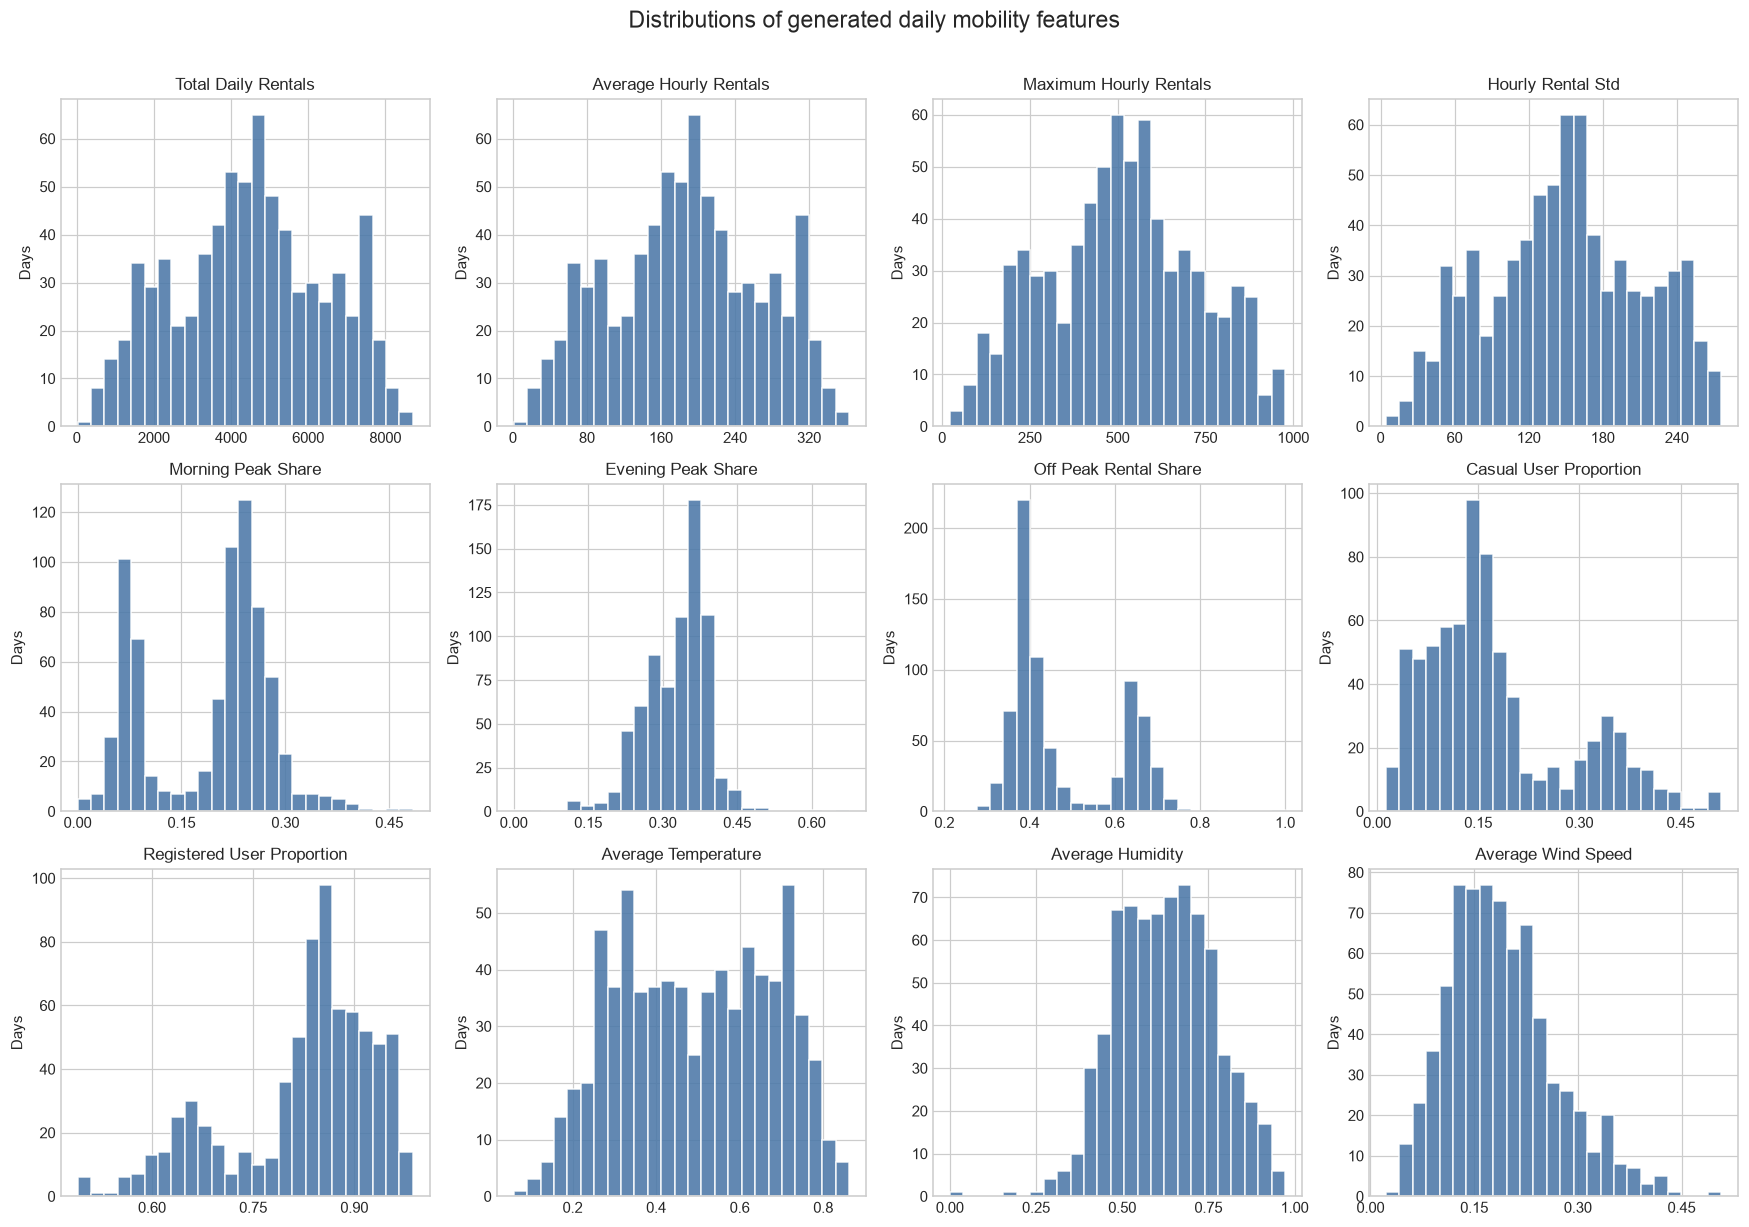

In [23]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for axis, feature in zip(axes.flat, daily_mobility_features.columns):
    axis.hist(daily_mobility_features[feature], bins=25, color=BLUE, alpha=0.88, edgecolor="white")
    axis.set_title(feature.replace("_", " ").title())
    axis.set_ylabel("Days")
    axis.xaxis.set_major_locator(MaxNLocator(5))

fig.suptitle("Distributions of generated daily mobility features", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

### 2. Standardized boxplots of the selected clustering features

Standardized values allow features with different units to be compared on the same axis. Points beyond the whiskers are retained because they may be genuine unusual mobility days.

/var/folders/ty/llmc1ng51qg25r_6j0t2mgbh0000gn/T/ipykernel_99650/3959492003.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  box = axis.boxplot(


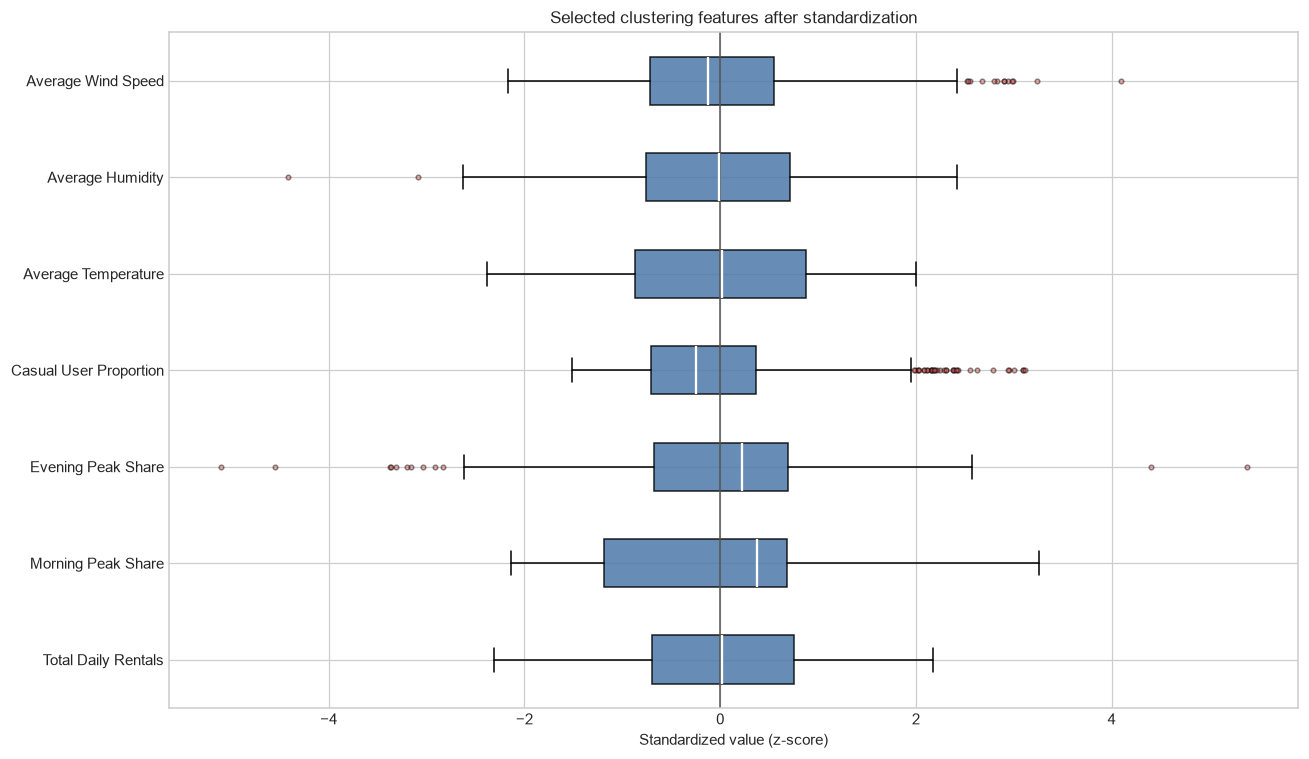

In [24]:
readable_selected_names = [name.replace("_", " ").title() for name in selected_feature_columns]
fig, axis = plt.subplots(figsize=(12, 7))
box = axis.boxplot(
    [clustering_data_scaled[column] for column in selected_feature_columns],
    vert=False,
    tick_labels=readable_selected_names,
    patch_artist=True,
    medianprops={"color": "white", "linewidth": 1.5},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.45, "markerfacecolor": RED},
)
for patch in box["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.85)
axis.axvline(0, color="#555555", linewidth=1)
axis.set_xlabel("Standardized value (z-score)")
axis.set_title("Selected clustering features after standardization")
fig.tight_layout()
plt.show()

### 3. Correlation heatmap

The lower-triangle heatmap uses all 12 generated features so that both exact and strong redundancy remain visible.

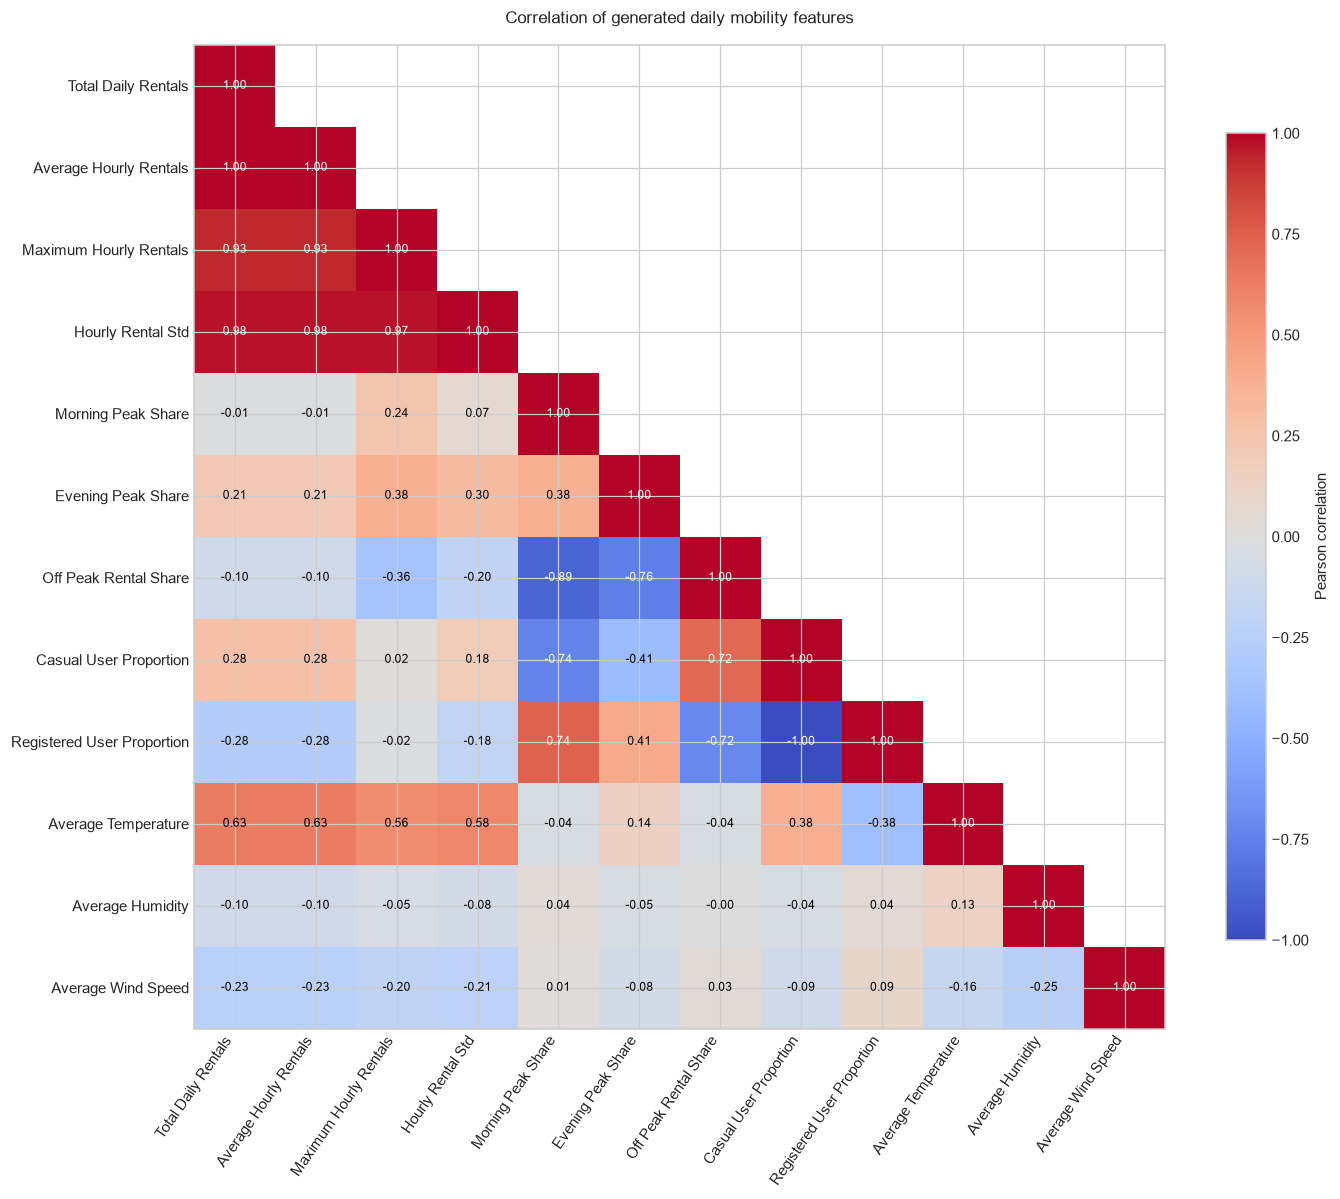

In [25]:
correlation_for_plot = daily_mobility_features.corr()
mask = np.triu(np.ones_like(correlation_for_plot, dtype=bool), k=1)
masked_correlation = np.ma.masked_where(mask, correlation_for_plot.to_numpy())
labels = [name.replace("_", " ").title() for name in correlation_for_plot.columns]

fig, axis = plt.subplots(figsize=(13, 11))
image = axis.imshow(masked_correlation, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
axis.set_xticks(range(len(labels)), labels=labels, rotation=55, ha="right")
axis.set_yticks(range(len(labels)), labels=labels)

for row in range(len(labels)):
    for column in range(row + 1):
        value = correlation_for_plot.iloc[row, column]
        text_color = "white" if abs(value) > 0.65 else "black"
        axis.text(column, row, f"{value:.2f}", ha="center", va="center",
                  fontsize=8, color=text_color)

colorbar = fig.colorbar(image, ax=axis, shrink=0.82)
colorbar.set_label("Pearson correlation")
axis.set_title("Correlation of generated daily mobility features", pad=14)
fig.tight_layout()
plt.show()

### 4. Daily rental demand over time

The raw daily series shows short-term variation, while the 30-day moving average makes seasonal and year-to-year demand changes easier to see. Severely incomplete dates are marked but retained.

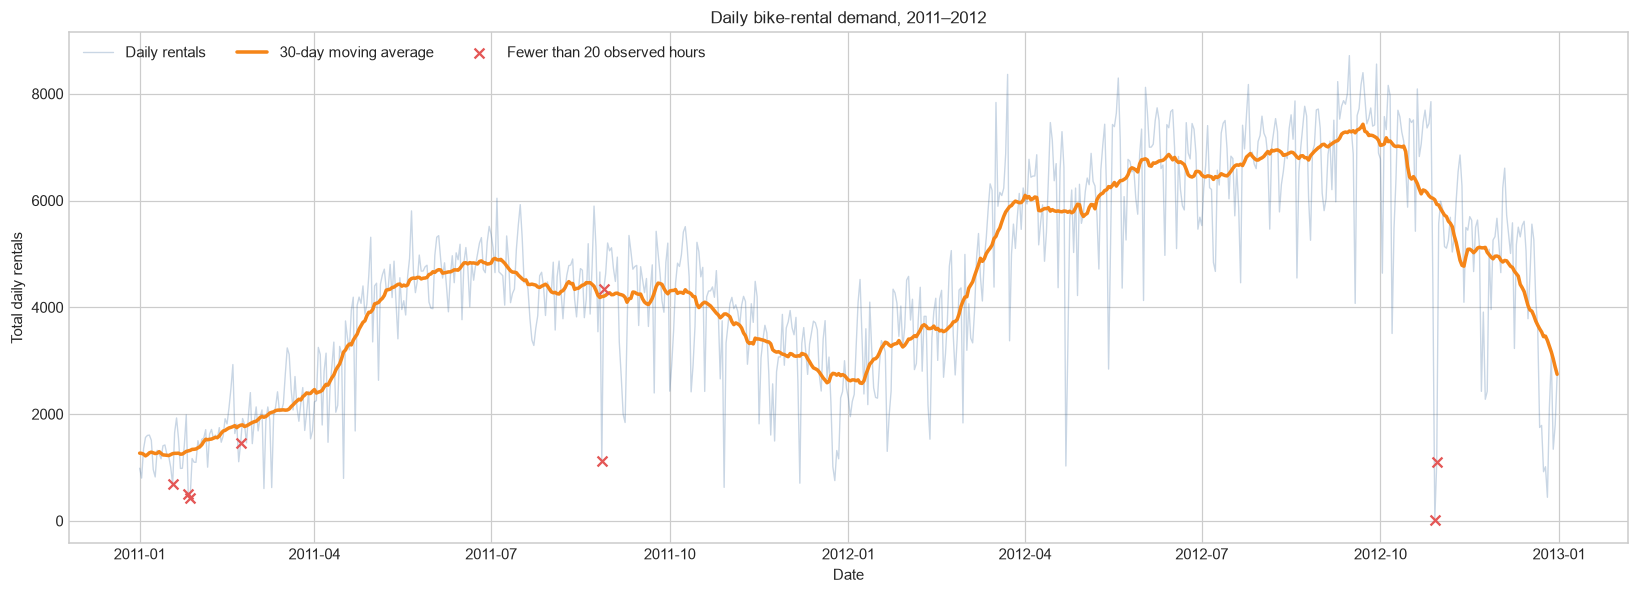

In [26]:
daily_total_series = daily_mobility_features["total_daily_rentals"]
rolling_30_day_demand = daily_total_series.rolling(window=30, center=True, min_periods=15).mean()

fig, axis = plt.subplots(figsize=(15, 5.5))
axis.plot(daily_total_series.index, daily_total_series, color=BLUE, alpha=0.30, linewidth=0.9,
          label="Daily rentals")
axis.plot(rolling_30_day_demand.index, rolling_30_day_demand, color=ORANGE, linewidth=2.3,
          label="30-day moving average")
axis.scatter(severe_dates, daily_total_series.loc[severe_dates], color=RED, marker="x", s=42,
             linewidth=1.5, label="Fewer than 20 observed hours", zorder=3)
axis.set_title("Daily bike-rental demand, 2011–2012")
axis.set_xlabel("Date")
axis.set_ylabel("Total daily rentals")
axis.legend(ncol=3, loc="upper left")
fig.tight_layout()
plt.show()

### 5. Average hourly profiles: working and non-working days

This plot compares the within-day demand shape. Zero-filled absent rental hours are included so averages use a consistent 24-hour day.

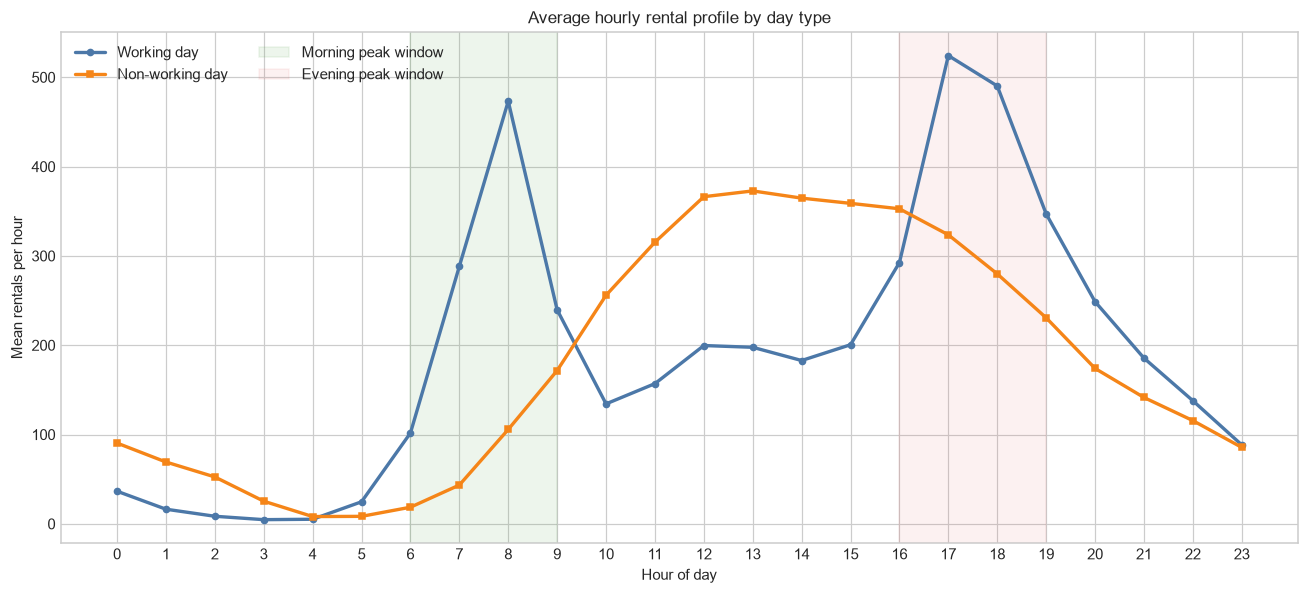

In [27]:
hourly_profile_source = hourly_24h.merge(
    daily_context[["workingday"]], left_on="dteday", right_index=True,
    how="left", validate="many_to_one"
)
average_hourly_profiles = (
    hourly_profile_source.groupby(["workingday", "hr"])["cnt"]
    .mean().unstack(0)
    .rename(columns={0: "Non-working day", 1: "Working day"})
)

fig, axis = plt.subplots(figsize=(12, 5.5))
axis.plot(average_hourly_profiles.index, average_hourly_profiles["Working day"],
          color=BLUE, marker="o", markersize=4, linewidth=2.2, label="Working day")
axis.plot(average_hourly_profiles.index, average_hourly_profiles["Non-working day"],
          color=ORANGE, marker="s", markersize=4, linewidth=2.2, label="Non-working day")
axis.axvspan(6, 9, color=TEAL, alpha=0.10, label="Morning peak window")
axis.axvspan(16, 19, color=RED, alpha=0.08, label="Evening peak window")
axis.set_xticks(range(24))
axis.set_xlabel("Hour of day")
axis.set_ylabel("Mean rentals per hour")
axis.set_title("Average hourly rental profile by day type")
axis.legend(ncol=2)
fig.tight_layout()
plt.show()

### 6. Two-dimensional PCA visualisation

PCA is fitted to the seven-feature standardized clustering dataset. Colour represents total demand and the severely incomplete days are overlaid as crosses.

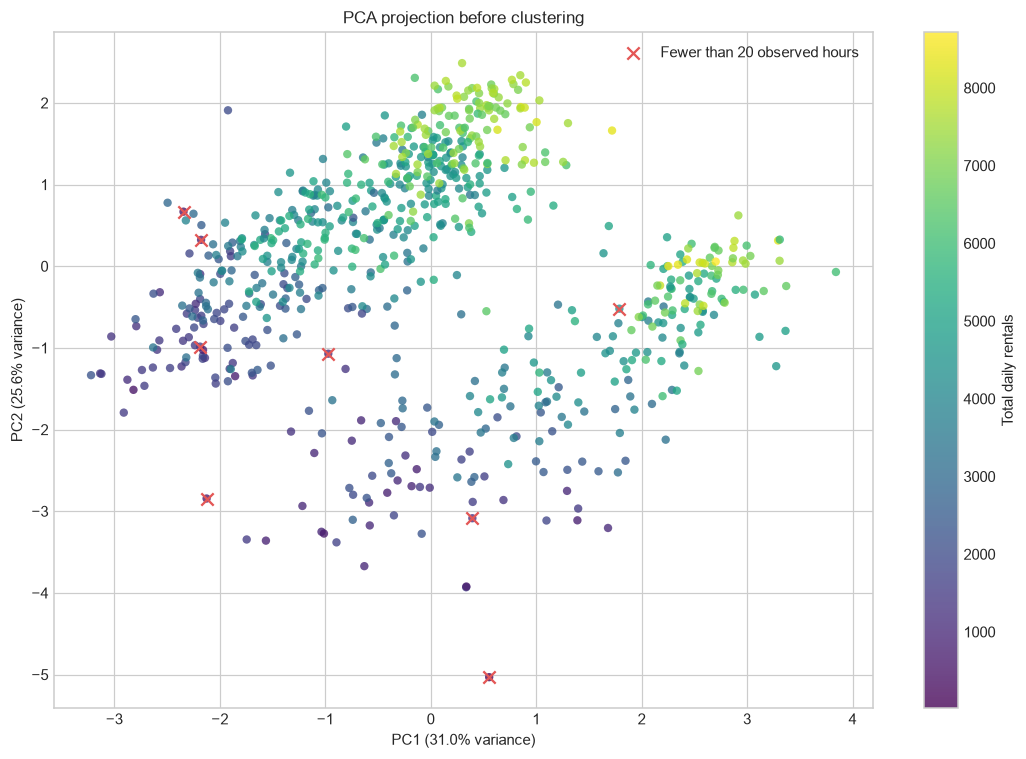

,PC1,PC2
total_daily_rentals,0.354,0.508
morning_peak_share,-0.487,0.374
evening_peak_share,-0.249,0.507
casual_user_proportion,0.620,-0.177
average_temperature,0.404,0.464
average_humidity,0.020,0.100
average_wind_speed,-0.167,-0.297


Variance explained by PC1 and PC2: 56.6%


In [28]:
pca_model = PCA(n_components=2)
pca_coordinates = pca_model.fit_transform(clustering_data_scaled)
pca_scores = pd.DataFrame(
    pca_coordinates, index=clustering_data_scaled.index, columns=["PC1", "PC2"]
)
pca_scores.index.name = "dteday"
pca_loadings = pd.DataFrame(
    pca_model.components_.T, index=selected_feature_columns, columns=["PC1", "PC2"]
)

fig, axis = plt.subplots(figsize=(10, 7))
points = axis.scatter(
    pca_scores["PC1"], pca_scores["PC2"],
    c=clustering_data_original["total_daily_rentals"], cmap="viridis",
    s=30, alpha=0.78, edgecolors="none",
)
axis.scatter(pca_scores.loc[severe_dates, "PC1"], pca_scores.loc[severe_dates, "PC2"],
             color=RED, marker="x", s=65, linewidth=1.5,
             label="Fewer than 20 observed hours")
axis.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} variance)")
axis.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} variance)")
axis.set_title("PCA projection before clustering")
axis.legend(loc="best")
colorbar = fig.colorbar(points, ax=axis)
colorbar.set_label("Total daily rentals")
fig.tight_layout()
plt.show()

display(pca_loadings.round(3))
print(f"Variance explained by PC1 and PC2: {pca_model.explained_variance_ratio_.sum():.1%}")

### Main patterns observed before clustering

- The daily demand features are broadly symmetric, while user composition and wind speed show only moderate skew; transformations are therefore unnecessary.
- Total, mean, maximum, and standard deviation of rentals carry strongly overlapping demand information. The two user proportions and the three time-period shares also contain exact dependencies, supporting the feature removals in Part 1.3.
- Demand has a strong seasonal pattern and is generally higher in 2012 than in 2011. The unusually low Hurricane Sandy dates remain visible rather than being removed.
- Working days show commuting-shaped morning and evening peaks, whereas non-working days have a broader midday peak consistent with leisure travel.
- The first two principal components explain a majority, but not all, of the standardized variation. PCA is suitable for visual inspection, while clustering should remain in the complete seven-dimensional standardized space.

# Part 2 — Apply and analyse clustering methods

All algorithms below use the same seven-dimensional standardized dataset, `clustering_data_scaled`. PCA coordinates are used only to visualise assignments; the clustering itself is performed in the full standardized feature space.

In [30]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage as hierarchy_linkage

KMEANS_RANDOM_STATE = 42
CLUSTER_CMAP = plt.get_cmap("tab10")

def plot_pca_assignments(label_series, title, label_names=None, noise_label=None):
    """Plot cluster assignments on the existing PCA coordinates."""
    labels = pd.Series(label_series, index=pca_scores.index, name="cluster")
    fig, axis = plt.subplots(figsize=(9.5, 6.5))
    regular_labels = sorted(label for label in labels.unique() if label != noise_label)
    for position, label in enumerate(regular_labels):
        mask = labels.eq(label)
        display_name = label_names.get(label, f"Cluster {label}") if label_names else f"Cluster {label}"
        axis.scatter(pca_scores.loc[mask, "PC1"], pca_scores.loc[mask, "PC2"],
                     s=31, alpha=0.78, color=CLUSTER_CMAP(position), label=display_name)
    if noise_label is not None and labels.eq(noise_label).any():
        noise_mask = labels.eq(noise_label)
        axis.scatter(pca_scores.loc[noise_mask, "PC1"], pca_scores.loc[noise_mask, "PC2"],
                     s=39, alpha=0.75, color="#555555", marker="x", label="Noise (-1)")
    axis.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} variance)")
    axis.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} variance)")
    axis.set_title(title)
    axis.legend(ncol=2, loc="best")
    fig.tight_layout()
    plt.show()

## Part 2.1 — K-means clustering

Candidate values from 2 to 10 are compared using both inertia (the elbow method) and silhouette score. Fifty initialisations and a fixed seed reduce sensitivity to an unlucky initial centroid placement.

,inertia,silhouette
k,,
1,5117.0000,NaN
2,3817.9591,0.2883
3,3097.3675,0.2535
4,2700.2916,0.2575
5,2433.0172,0.2471
6,2257.1861,0.2539
7,2107.1672,0.2203
8,1994.1114,0.2297
9,1900.3534,0.2130


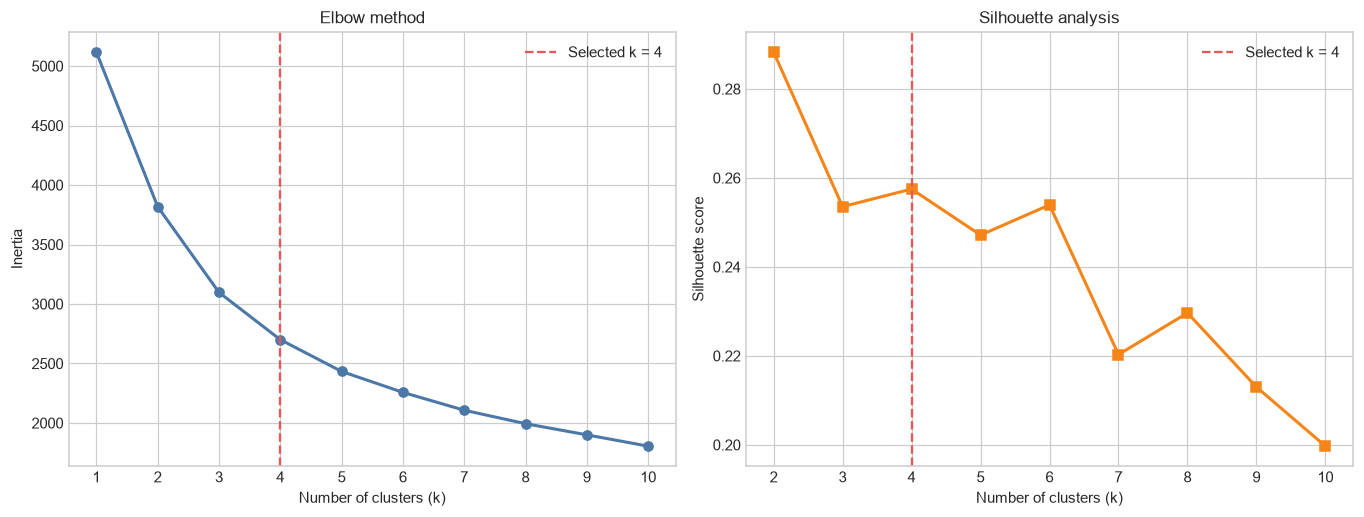

In [31]:
kmeans_rows = []
kmeans_candidate_models = {}
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=KMEANS_RANDOM_STATE, n_init=50)
    labels = model.fit_predict(X_clustering)
    kmeans_candidate_models[k] = model
    kmeans_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": np.nan if k == 1 else silhouette_score(X_clustering, labels),
    })

kmeans_selection_metrics = pd.DataFrame(kmeans_rows).set_index("k")
display(kmeans_selection_metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
axes[0].plot(kmeans_selection_metrics.index, kmeans_selection_metrics["inertia"],
             color=BLUE, marker="o", linewidth=2)
axes[0].axvline(4, color=RED, linestyle="--", label="Selected k = 4")
axes[0].set(title="Elbow method", xlabel="Number of clusters (k)", ylabel="Inertia")
axes[0].legend()

axes[1].plot(kmeans_selection_metrics.index[1:], kmeans_selection_metrics["silhouette"].iloc[1:],
             color=ORANGE, marker="s", linewidth=2)
axes[1].axvline(4, color=RED, linestyle="--", label="Selected k = 4")
axes[1].set(title="Silhouette analysis", xlabel="Number of clusters (k)",
            ylabel="Silhouette score")
axes[1].legend()
for axis in axes:
    axis.set_xticks(range(1 if axis is axes[0] else 2, 11))
fig.tight_layout()
plt.show()

### Final K-means model

The elbow becomes pronounced around four clusters: the relative reduction in inertia falls below 10% after this point. Although `k=2` has the highest silhouette score, it produces only a broad commuter-versus-leisure split. `k=4` has a better silhouette than its adjacent `k=3` and `k=5` solutions and yields four distinct, practically interpretable mobility regimes.

In [32]:
KMEANS_FINAL_K = 4
kmeans_model = kmeans_candidate_models[KMEANS_FINAL_K]
kmeans_labels = pd.Series(kmeans_model.labels_, index=clustering_data_scaled.index,
                          name="kmeans_cluster")
kmeans_centroids_scaled = pd.DataFrame(
    kmeans_model.cluster_centers_, columns=selected_feature_columns,
    index=pd.Index(range(KMEANS_FINAL_K), name="cluster")
)
kmeans_centroids_original = pd.DataFrame(
    clustering_scaler.inverse_transform(kmeans_model.cluster_centers_),
    columns=selected_feature_columns, index=kmeans_centroids_scaled.index,
)
kmeans_cluster_sizes = kmeans_labels.value_counts().sort_index().rename("days")

kmeans_preliminary_names = {
    0: "Cool low-demand mixed-use days",
    1: "Warm high-demand commuting days",
    2: "Warm high-demand leisure days",
    3: "Cool registered-commuter days",
}
kmeans_centroid_report = kmeans_centroids_original.join(kmeans_cluster_sizes)
kmeans_centroid_report.insert(0, "preliminary_name",
                              pd.Series(kmeans_preliminary_names))
display(kmeans_centroid_report.round(3))
print(f"Final K-means silhouette: {silhouette_score(X_clustering, kmeans_labels):.4f}")

,preliminary_name,total_daily_rentals,morning_peak_share,evening_peak_share,casual_user_proportion,average_temperature,average_humidity,average_wind_speed,days
cluster,,,,,,,,,
0,Cool low-demand mixed-use days,2471.495,0.082,0.249,0.204,0.305,0.609,0.217,107
1,Warm high-demand commuting days,5757.489,0.228,0.369,0.155,0.637,0.636,0.174,274
2,Warm high-demand leisure days,5652.723,0.075,0.279,0.357,0.612,0.639,0.172,130
3,Cool registered-commuter days,3253.741,0.268,0.347,0.080,0.343,0.621,0.210,220


Final K-means silhouette: 0.2575


In [ ]:
plot_pca_assignments(kmeans_labels, "K-means clusters projected onto PCA space",
                     label_names=kmeans_preliminary_names)

### Preliminary K-means interpretation

The centroids separate low- and high-demand days while preserving behavioural differences. Clusters 1 and 3 have stronger commuting peaks and lower casual-user shares. Cluster 2 combines high demand with the largest casual-user proportion and weak morning concentration, consistent with leisure-oriented use. Cluster 0 contains cooler, lower-demand days with relatively weak peak concentration. These labels will be validated against weekday, season, holiday, and weather context in Part 4.

## Part 2.2 — Hierarchical clustering using AGNES

Agglomerative clustering is evaluated with Euclidean distance and single, complete, and average linkage. Cuts from 2 to 10 clusters are compared quantitatively; the dendrogram is not used as the only selection criterion.

In [33]:
agnes_rows = []
agnes_candidate_labels = {}
for linkage_method in ["single", "complete", "average"]:
    for number_of_clusters in range(2, 11):
        model = AgglomerativeClustering(
            n_clusters=number_of_clusters, linkage=linkage_method, metric="euclidean"
        )
        labels = model.fit_predict(X_clustering)
        sizes = pd.Series(labels).value_counts().sort_values(ascending=False)
        agnes_candidate_labels[(linkage_method, number_of_clusters)] = labels
        agnes_rows.append({
            "linkage": linkage_method,
            "clusters": number_of_clusters,
            "silhouette": silhouette_score(X_clustering, labels),
            "davies_bouldin": davies_bouldin_score(X_clustering, labels),
            "smallest_cluster": int(sizes.min()),
            "largest_cluster_share": sizes.max() / len(labels),
            "cluster_sizes": ", ".join(map(str, sizes.tolist())),
        })

agnes_evaluation = pd.DataFrame(agnes_rows)
display(agnes_evaluation.round({"silhouette": 4, "davies_bouldin": 4,
                                "largest_cluster_share": 3}))

,linkage,clusters,silhouette,davies_bouldin,smallest_cluster,largest_cluster_share,cluster_sizes
0,single,2,0.4750,0.5351,2,0.997,"729, 2"
1,single,3,0.3700,0.5137,1,0.996,"728, 2, 1"
2,single,4,0.3437,0.4918,1,0.995,"727, 2, 1, 1"
3,single,5,0.3162,0.4797,1,0.993,"726, 2, 1, 1, 1"
4,single,6,0.1944,0.5283,1,0.992,"725, 2, 1, 1, 1, 1"
5,single,7,0.1960,0.5047,1,0.990,"724, 2, 1, 1, 1, 1, 1"
6,single,8,0.0738,0.5522,1,0.989,"723, 2, 1, 1, 1, 1, 1, 1"
7,single,9,0.0597,0.5456,1,0.988,"722, 2, 1, 1, 1, 1, 1, 1, 1"
8,single,10,0.0269,0.5561,1,0.986,"721, 2, 1, 1, 1, 1, 1, 1, 1, 1"
9,complete,2,0.4750,0.5351,2,0.997,"729, 2"


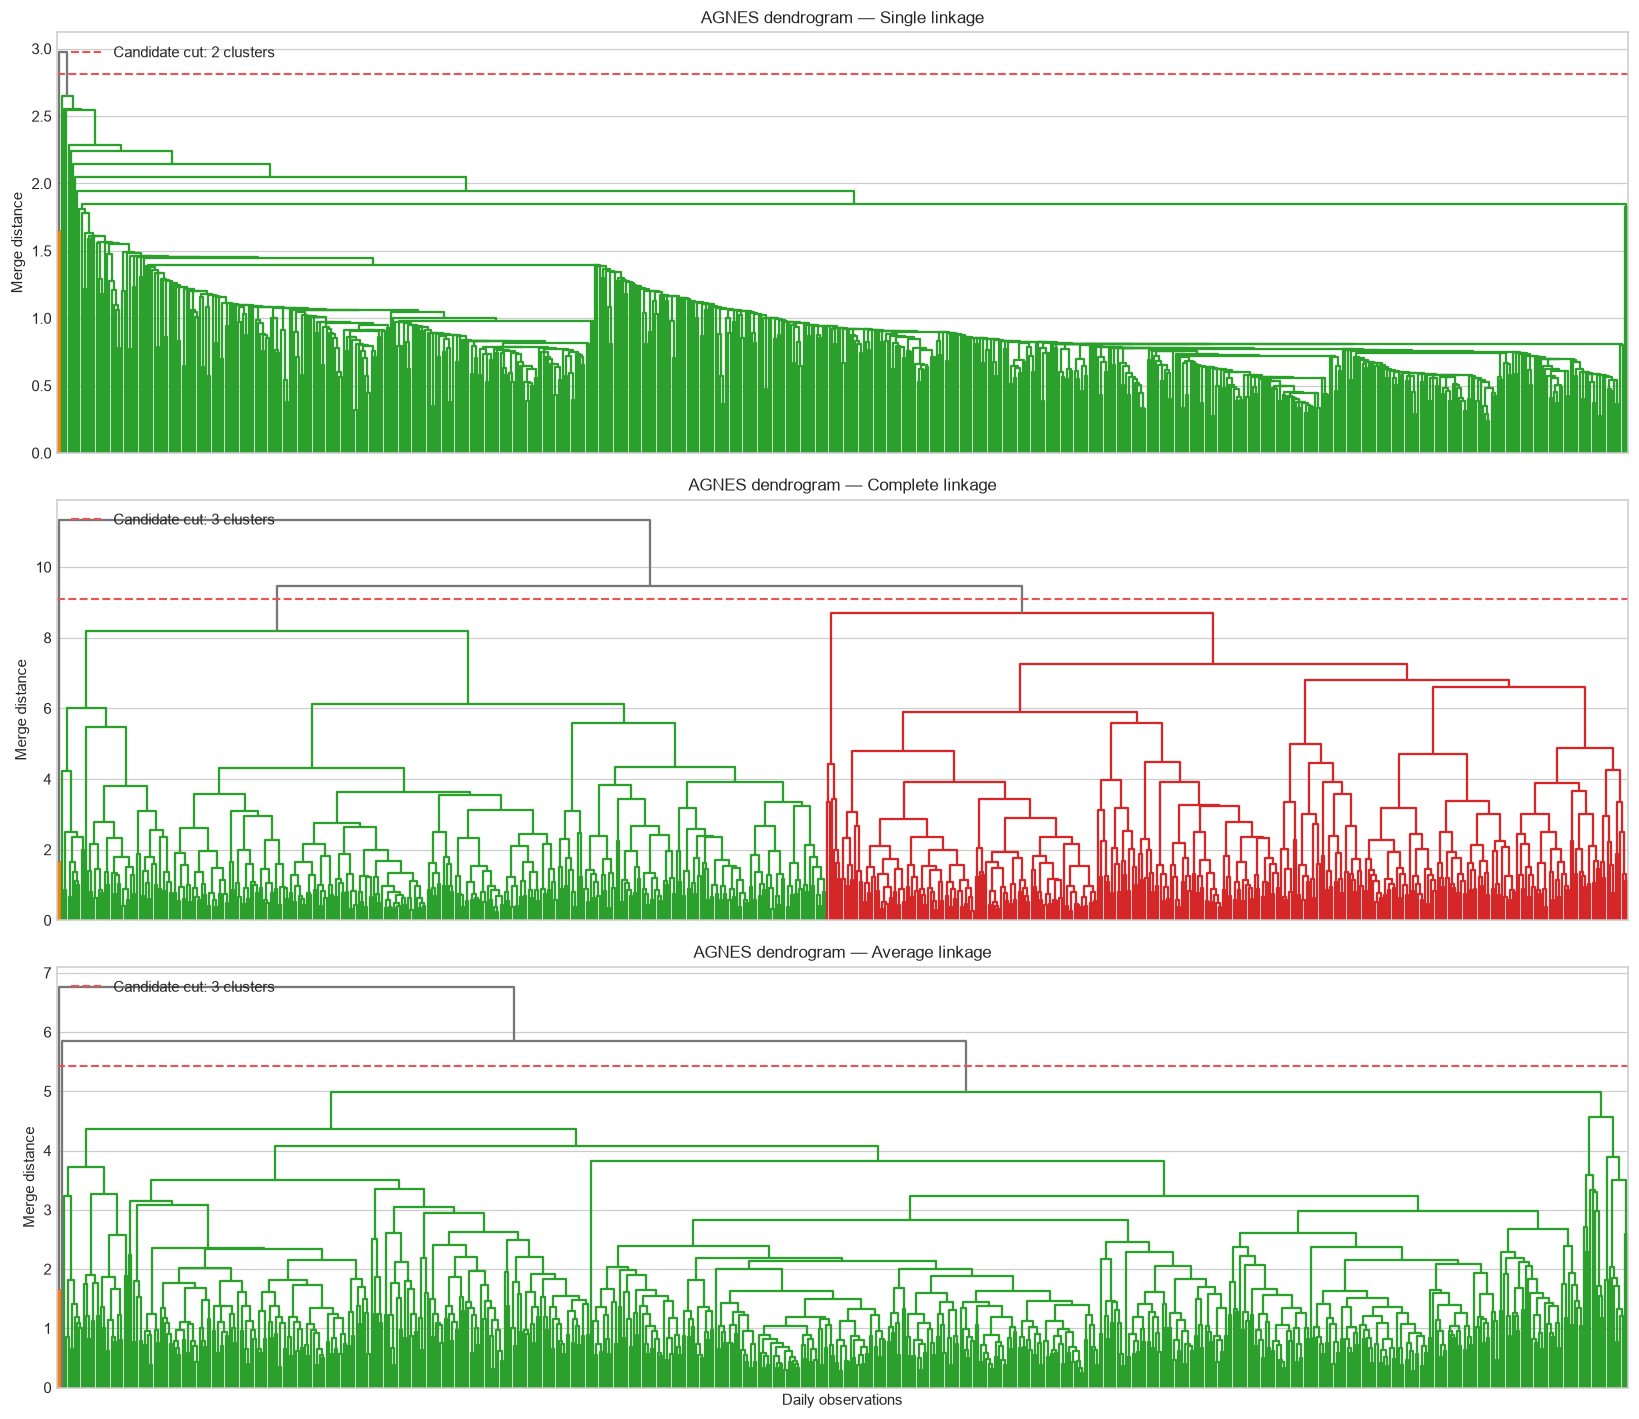

In [34]:
agnes_linkage_matrices = {
    method: hierarchy_linkage(X_clustering, method=method, metric="euclidean")
    for method in ["single", "complete", "average"]
}
agnes_candidate_cuts = {"single": 2, "complete": 3, "average": 3}

def dendrogram_cut_height(linkage_matrix, clusters):
    sample_count = linkage_matrix.shape[0] + 1
    lower_merge = linkage_matrix[sample_count - clusters - 1, 2]
    upper_merge = linkage_matrix[sample_count - clusters, 2]
    return (lower_merge + upper_merge) / 2

fig, axes = plt.subplots(3, 1, figsize=(15, 13))
for axis, method in zip(axes, ["single", "complete", "average"]):
    cut_clusters = agnes_candidate_cuts[method]
    cut_height = dendrogram_cut_height(agnes_linkage_matrices[method], cut_clusters)
    dendrogram(agnes_linkage_matrices[method], ax=axis, no_labels=True,
               color_threshold=cut_height, above_threshold_color="#777777")
    axis.axhline(cut_height, color=RED, linestyle="--", linewidth=1.4,
                label=f"Candidate cut: {cut_clusters} clusters")
    axis.set_title(f"AGNES dendrogram — {method.title()} linkage")
    axis.set_ylabel("Merge distance")
    axis.legend(loc="upper left")
axes[-1].set_xlabel("Daily observations")
fig.tight_layout()
plt.show()

### Linkage comparison and selected AGNES result

Single linkage exhibits severe chaining: at its apparently strong two-cluster cut, 729 days are linked into one cluster and only two form the other. Average linkage behaves similarly, repeatedly isolating tiny groups. These high silhouette scores are therefore misleading. Complete linkage produces the most meaningful structure: at three clusters it forms two comparably sized mobility groups plus a two-day extreme group. Complete linkage with three clusters is selected because it limits chaining and provides substantially better balance and interpretability than the other linkage methods.

,total_daily_rentals,morning_peak_share,evening_peak_share,casual_user_proportion,average_temperature,average_humidity,average_wind_speed,days
agnes_cluster,,,,,,,,
0,3613.276,0.206,0.325,0.137,0.420,0.688,0.178,373
1,557.000,0.000,0.644,0.024,0.206,0.775,0.130,2
2,5460.149,0.177,0.330,0.217,0.576,0.564,0.204,356


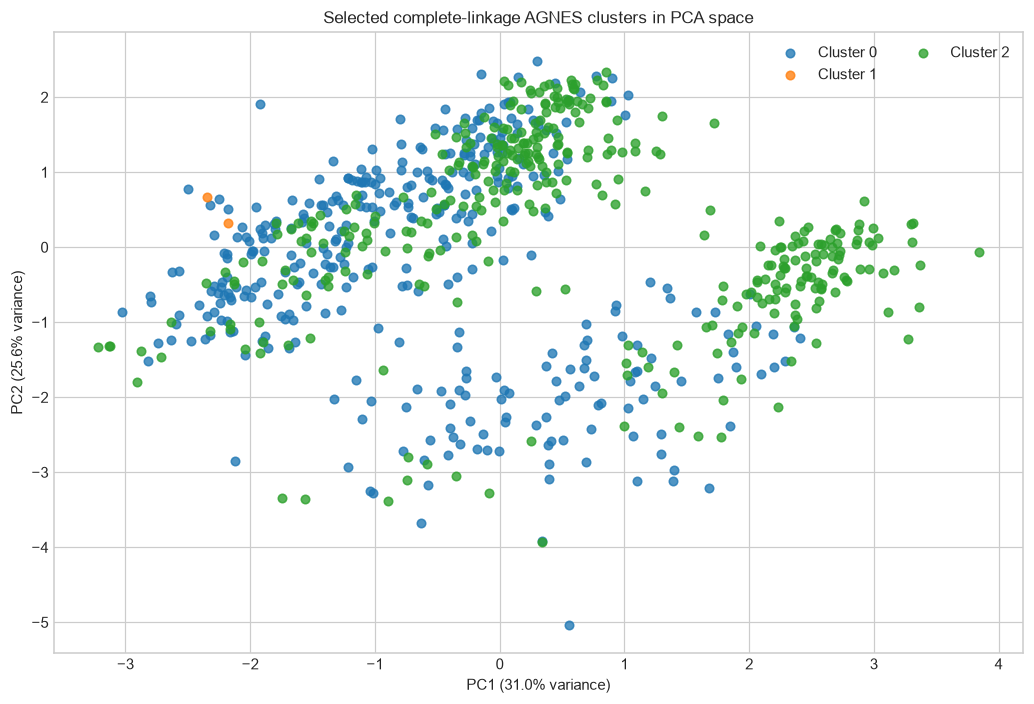

In [35]:
AGNES_SELECTED_LINKAGE = "complete"
AGNES_SELECTED_K = 3
agnes_model = AgglomerativeClustering(
    n_clusters=AGNES_SELECTED_K, linkage=AGNES_SELECTED_LINKAGE, metric="euclidean"
)
agnes_labels = pd.Series(agnes_model.fit_predict(X_clustering),
                         index=clustering_data_scaled.index, name="agnes_cluster")
agnes_cluster_sizes = agnes_labels.value_counts().sort_index().rename("days")
agnes_profiles_original = clustering_data_original.join(agnes_labels).groupby("agnes_cluster").mean()
display(agnes_profiles_original.join(agnes_cluster_sizes).round(3))
plot_pca_assignments(agnes_labels, "Selected complete-linkage AGNES clusters in PCA space")

## Part 2.3 — DBSCAN

`min_samples` is set to twice the number of clustering dimensions (`2 × 7 = 14`), a conservative rule that requires a meaningful local neighbourhood in seven-dimensional space. The sorted 14-nearest-neighbour distance plot is used to examine `eps`.

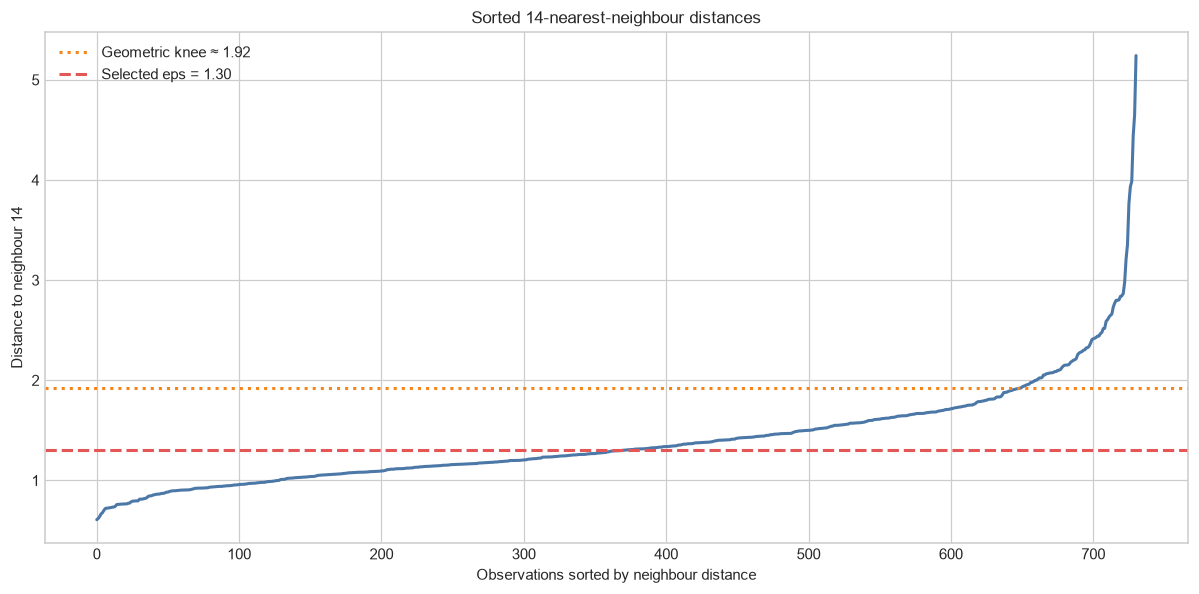

Geometric knee estimate: eps = 1.921


In [36]:
DBSCAN_MIN_SAMPLES = 2 * clustering_data_scaled.shape[1]
nearest_neighbours = NearestNeighbors(n_neighbors=DBSCAN_MIN_SAMPLES)
nearest_neighbours.fit(X_clustering)
neighbour_distances, _ = nearest_neighbours.kneighbors(X_clustering)
sorted_k_distances = np.sort(neighbour_distances[:, -1])

# A reproducible geometric knee estimate; the plot is also inspected for a lower shoulder.
normalised_positions = np.linspace(0, 1, len(sorted_k_distances))
normalised_distances = (sorted_k_distances - sorted_k_distances.min()) / (
    sorted_k_distances.max() - sorted_k_distances.min()
)
estimated_knee_index = int(np.argmax(normalised_positions - normalised_distances))
estimated_knee_eps = float(sorted_k_distances[estimated_knee_index])
DBSCAN_EPS = 1.30

fig, axis = plt.subplots(figsize=(11, 5.5))
axis.plot(range(len(sorted_k_distances)), sorted_k_distances, color=BLUE, linewidth=2)
axis.axhline(estimated_knee_eps, color=ORANGE, linestyle=":", linewidth=2,
             label=f"Geometric knee ≈ {estimated_knee_eps:.2f}")
axis.axhline(DBSCAN_EPS, color=RED, linestyle="--", linewidth=2,
             label=f"Selected eps = {DBSCAN_EPS:.2f}")
axis.set_title(f"Sorted {DBSCAN_MIN_SAMPLES}-nearest-neighbour distances")
axis.set_xlabel("Observations sorted by neighbour distance")
axis.set_ylabel(f"Distance to neighbour {DBSCAN_MIN_SAMPLES}")
axis.legend()
fig.tight_layout()
plt.show()
print(f"Geometric knee estimate: eps = {estimated_knee_eps:.3f}")

### DBSCAN parameter sensitivity

The geometric knee near 1.92 merges nearly all observations into one density-connected cluster. A lower shoulder at `eps = 1.30` is selected to preserve meaningful density substructure while retaining most days. Smaller, larger, and lower-density alternatives are tested explicitly. Silhouette values in this table exclude noise and are used only as a sensitivity diagnostic.

In [37]:
dbscan_settings = [
    ("Primary", 1.30, 14),
    ("Smaller eps", 1.20, 14),
    ("Larger eps", 1.40, 14),
    ("Lower min_samples", 1.30, 10),
]
dbscan_rows = []
dbscan_candidate_labels = {}
for setting_name, eps_value, min_samples_value in dbscan_settings:
    labels = DBSCAN(eps=eps_value, min_samples=min_samples_value).fit_predict(X_clustering)
    dbscan_candidate_labels[setting_name] = labels
    non_noise = labels != -1
    cluster_labels = sorted(set(labels) - {-1})
    sizes = pd.Series(labels[non_noise]).value_counts().sort_values(ascending=False)
    sensitivity_silhouette = (
        silhouette_score(X_clustering[non_noise], labels[non_noise])
        if len(cluster_labels) >= 2 else np.nan
    )
    dbscan_rows.append({
        "setting": setting_name,
        "eps": eps_value,
        "min_samples": min_samples_value,
        "clusters": len(cluster_labels),
        "noise_points": int((~non_noise).sum()),
        "noise_share": (~non_noise).mean(),
        "non_noise_silhouette": sensitivity_silhouette,
        "cluster_sizes": ", ".join(map(str, sizes.tolist())),
    })

dbscan_sensitivity = pd.DataFrame(dbscan_rows).set_index("setting")
display(dbscan_sensitivity.round({"noise_share": 3, "non_noise_silhouette": 4}))

,eps,min_samples,clusters,noise_points,noise_share,non_noise_silhouette,cluster_sizes
setting,,,,,,,
Primary,1.3,14,3,168,0.230,0.2959,"426, 103, 34"
Smaller eps,1.2,14,3,236,0.323,0.2871,"390, 91, 14"
Larger eps,1.4,14,2,115,0.157,0.3270,"449, 167"
Lower min_samples,1.3,10,2,126,0.172,0.3277,"441, 164"


DBSCAN clusters: 3
Noise points: 168 (23.0%)


,days
dbscan_cluster,
-1,168
0,426
1,34
2,103


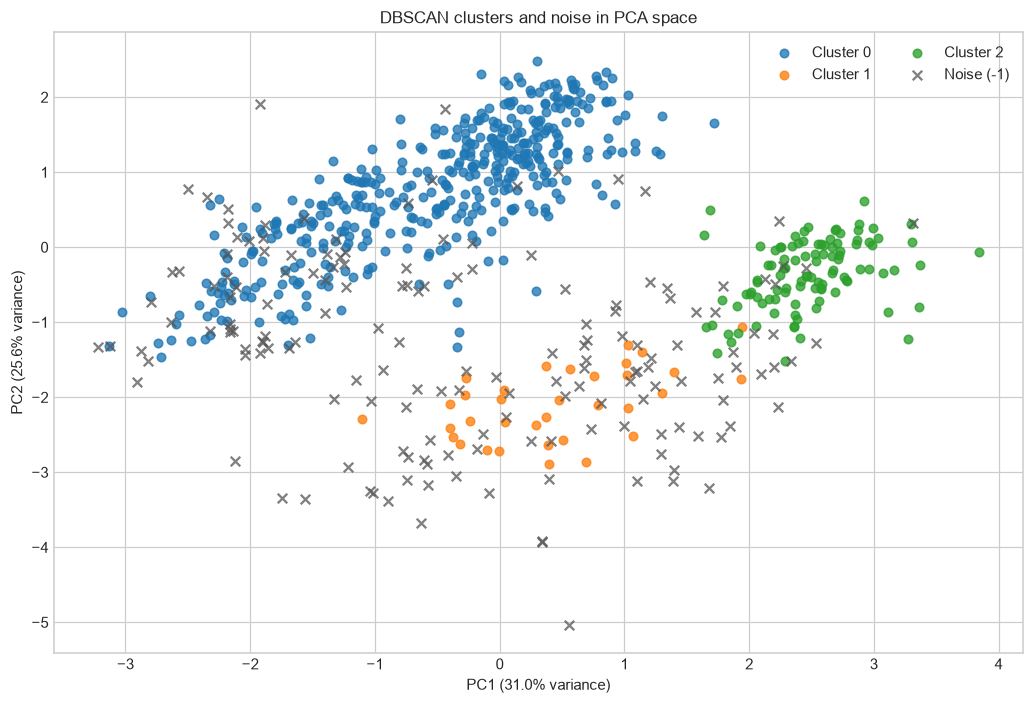

In [38]:
dbscan_model = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
dbscan_labels = pd.Series(dbscan_model.fit_predict(X_clustering),
                          index=clustering_data_scaled.index, name="dbscan_cluster")
dbscan_noise_dates = dbscan_labels.index[dbscan_labels.eq(-1)]
dbscan_cluster_count = dbscan_labels[dbscan_labels.ne(-1)].nunique()
dbscan_cluster_sizes = dbscan_labels.value_counts().sort_index().rename("days")

print(f"DBSCAN clusters: {dbscan_cluster_count}")
print(f"Noise points: {len(dbscan_noise_dates)} ({len(dbscan_noise_dates) / len(dbscan_labels):.1%})")
display(dbscan_cluster_sizes.to_frame())
plot_pca_assignments(dbscan_labels, "DBSCAN clusters and noise in PCA space", noise_label=-1)

In [39]:
severe_noise_overlap = severe_dates.intersection(dbscan_noise_dates)
noise_review = (
    daily_mobility_features.loc[dbscan_noise_dates]
    .join(daily_context.loc[dbscan_noise_dates])
    .sort_values("total_daily_rentals")
)
print(f"Severely incomplete days identified as noise: {len(severe_noise_overlap)} of {len(severe_dates)}")
display(noise_review.head(12))

Severely incomplete days identified as noise: 7 of 8


,total_daily_rentals,average_hourly_rentals,maximum_hourly_rentals,hourly_rental_std,morning_peak_share,evening_peak_share,off_peak_rental_share,casual_user_proportion,registered_user_proportion,average_temperature,average_humidity,average_wind_speed,season,year_code,month,holiday,weekday,workingday,dominant_weather,worst_weather,weekend,observed_hours,is_complete_day
dteday,,,,,,,,,,,,,,,,,,,,,,,
2012-10-29,22,0.916667,22,4.396179,0.000000,0.000000,1.000000,0.090909,0.909091,0.440000,0.880000,0.358200,4,1,10,0,1,1,3,3,0,1,False
2011-01-27,431,17.958333,104,30.861896,0.000000,0.675174,0.324826,0.034803,0.965197,0.195000,0.687500,0.113838,1,0,1,0,4,1,1,1,0,8,False
2012-12-26,441,18.375000,53,13.499421,0.263039,0.326531,0.410431,0.020408,0.979592,0.243333,0.823333,0.316546,1,1,12,0,3,1,3,3,0,24,True
2011-01-26,506,21.083333,72,21.750319,0.332016,0.122530,0.545455,0.067194,0.932806,0.217500,0.862500,0.293850,1,0,1,0,3,1,3,4,0,16,False
2011-03-06,605,25.208333,105,25.908459,0.062810,0.115702,0.821488,0.188430,0.811570,0.376522,0.948261,0.343287,1,0,3,0,0,0,2,3,1,23,False
2011-03-10,623,25.958333,111,26.347801,0.187801,0.433387,0.378812,0.073836,0.926164,0.389091,0.000000,0.261877,1,0,3,0,4,1,3,3,0,22,False
2011-10-29,627,26.125000,54,15.896311,0.082935,0.215311,0.701754,0.090909,0.909091,0.254167,0.882500,0.351371,4,0,10,0,6,0,3,3,1,24,True
2011-01-18,683,28.458333,133,40.804390,0.000000,0.612006,0.387994,0.013177,0.986823,0.216667,0.861667,0.146775,1,0,1,0,2,1,2,2,0,12,False
2011-12-07,705,29.375000,86,20.736065,0.303546,0.236879,0.459574,0.070922,0.929078,0.410000,0.970417,0.266175,4,0,12,0,3,1,3,3,0,24,True


### DBSCAN interpretation

The primary setting produces three density clusters and a substantial noise set, and the sensitivity table shows that both noise count and cluster count change as `eps` or `min_samples` changes. Seven of the eight severely incomplete days are classified as noise, including the Hurricane Sandy dates. Because all source integrity checks passed, these observations should not automatically be labelled data errors: they are more plausibly valid rare-demand, severe-weather, closure, or disruption days. Their incomplete-hour status must nevertheless be considered when interpreting them.

## Part 2 outputs

The final label vectors are combined below for use in the formal evaluation and comparison in Part 3. DBSCAN retains `-1` for noise.

In [40]:
part2_cluster_assignments = pd.concat(
    [kmeans_labels, agnes_labels, dbscan_labels], axis=1
)
assert part2_cluster_assignments.shape == (731, 3)
assert part2_cluster_assignments.notna().all().all()
assert kmeans_labels.nunique() == KMEANS_FINAL_K
assert agnes_labels.nunique() == AGNES_SELECTED_K
assert dbscan_cluster_count == 3
display(part2_cluster_assignments.head())
print("Part 2 clustering implementations completed successfully.")

,kmeans_cluster,agnes_cluster,dbscan_cluster
dteday,,,
2011-01-01,0,0,-1
2011-01-02,0,0,-1
2011-01-03,3,0,0
2011-01-04,3,0,0
2011-01-05,3,0,0


Part 2 clustering implementations completed successfully.


### Part 2 conclusion

K-means supplies four interpretable, reasonably balanced mobility regimes. AGNES demonstrates that linkage choice matters: single and average linkage chain most days together, while complete linkage produces two broad groups plus an extreme two-day group. DBSCAN finds three dense regions and explicitly identifies unusual days as noise, but its results are more parameter-sensitive. Part 3 will compare these meaningful solutions using a common evaluation framework.

# Part 3 — Clustering evaluation and comparison

The final K-means, AGNES, and DBSCAN results are evaluated in the same seven-dimensional standardized feature space. Metrics are interpreted together rather than treating one score as decisive.

## Part 3.1 — Common evaluation metrics

The comparison includes silhouette score, Davies–Bouldin index, mean pairwise intra-cluster distance, mean pairwise inter-cluster distance, their separation ratio, cluster-size balance, and observation coverage. Higher silhouette, inter/intra ratio, balance, and coverage are preferable; lower Davies–Bouldin and intra-cluster distance are preferable.

**DBSCAN noise handling:** observations labelled `-1` are excluded from silhouette, Davies–Bouldin, and intra/inter-distance calculations because noise is not a cluster. Noise remains included when reporting coverage and the full cluster-size distribution.

In [41]:
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import adjusted_rand_score

def evaluate_final_clustering(data, labels, exclude_noise=False):
    """Calculate common internal metrics in standardized Euclidean space."""
    labels = np.asarray(labels)
    evaluation_mask = labels != -1 if exclude_noise else np.ones(len(labels), dtype=bool)
    evaluated_data = np.asarray(data)[evaluation_mask]
    evaluated_labels = labels[evaluation_mask]

    distance_matrix = squareform(pdist(evaluated_data, metric="euclidean"))
    upper_rows, upper_columns = np.triu_indices(len(evaluated_data), k=1)
    upper_distances = distance_matrix[upper_rows, upper_columns]
    same_cluster = evaluated_labels[upper_rows] == evaluated_labels[upper_columns]
    mean_intra = upper_distances[same_cluster].mean()
    mean_inter = upper_distances[~same_cluster].mean()

    evaluated_sizes = pd.Series(evaluated_labels).value_counts()
    proportions = evaluated_sizes / evaluated_sizes.sum()
    normalised_entropy = -(proportions * np.log(proportions)).sum() / np.log(len(proportions))

    return {
        "clusters": evaluated_sizes.size,
        "evaluated_observations": evaluation_mask.sum(),
        "coverage": evaluation_mask.mean(),
        "silhouette": silhouette_score(evaluated_data, evaluated_labels),
        "davies_bouldin": davies_bouldin_score(evaluated_data, evaluated_labels),
        "mean_intra_distance": mean_intra,
        "mean_inter_distance": mean_inter,
        "inter_intra_ratio": mean_inter / mean_intra,
        "balance_entropy": normalised_entropy,
        "smallest_cluster": int(evaluated_sizes.min()),
        "largest_cluster": int(evaluated_sizes.max()),
    }

evaluation_results = pd.DataFrame({
    "K-means (k=4)": evaluate_final_clustering(X_clustering, kmeans_labels),
    "AGNES complete (k=3)": evaluate_final_clustering(X_clustering, agnes_labels),
    "DBSCAN": evaluate_final_clustering(X_clustering, dbscan_labels, exclude_noise=True),
}).T
display(evaluation_results.round(4))

,clusters,evaluated_observations,coverage,silhouette,davies_bouldin,mean_intra_distance,mean_inter_distance,inter_intra_ratio,balance_entropy,smallest_cluster,largest_cluster
K-means (k=4),4.0,731.0,1.0000,0.2575,1.4570,2.4743,3.9601,1.6005,0.9504,107.0,274.0
AGNES complete (k=3),3.0,731.0,1.0000,0.1149,1.9515,3.2963,3.7795,1.1466,0.6461,2.0,373.0
DBSCAN,3.0,563.0,0.7702,0.2959,1.0151,2.5705,3.9159,1.5234,0.6292,34.0,426.0


### Distance and validity comparison

The small multiples preserve the direction and scale of each metric instead of combining unlike measures into an arbitrary single score.

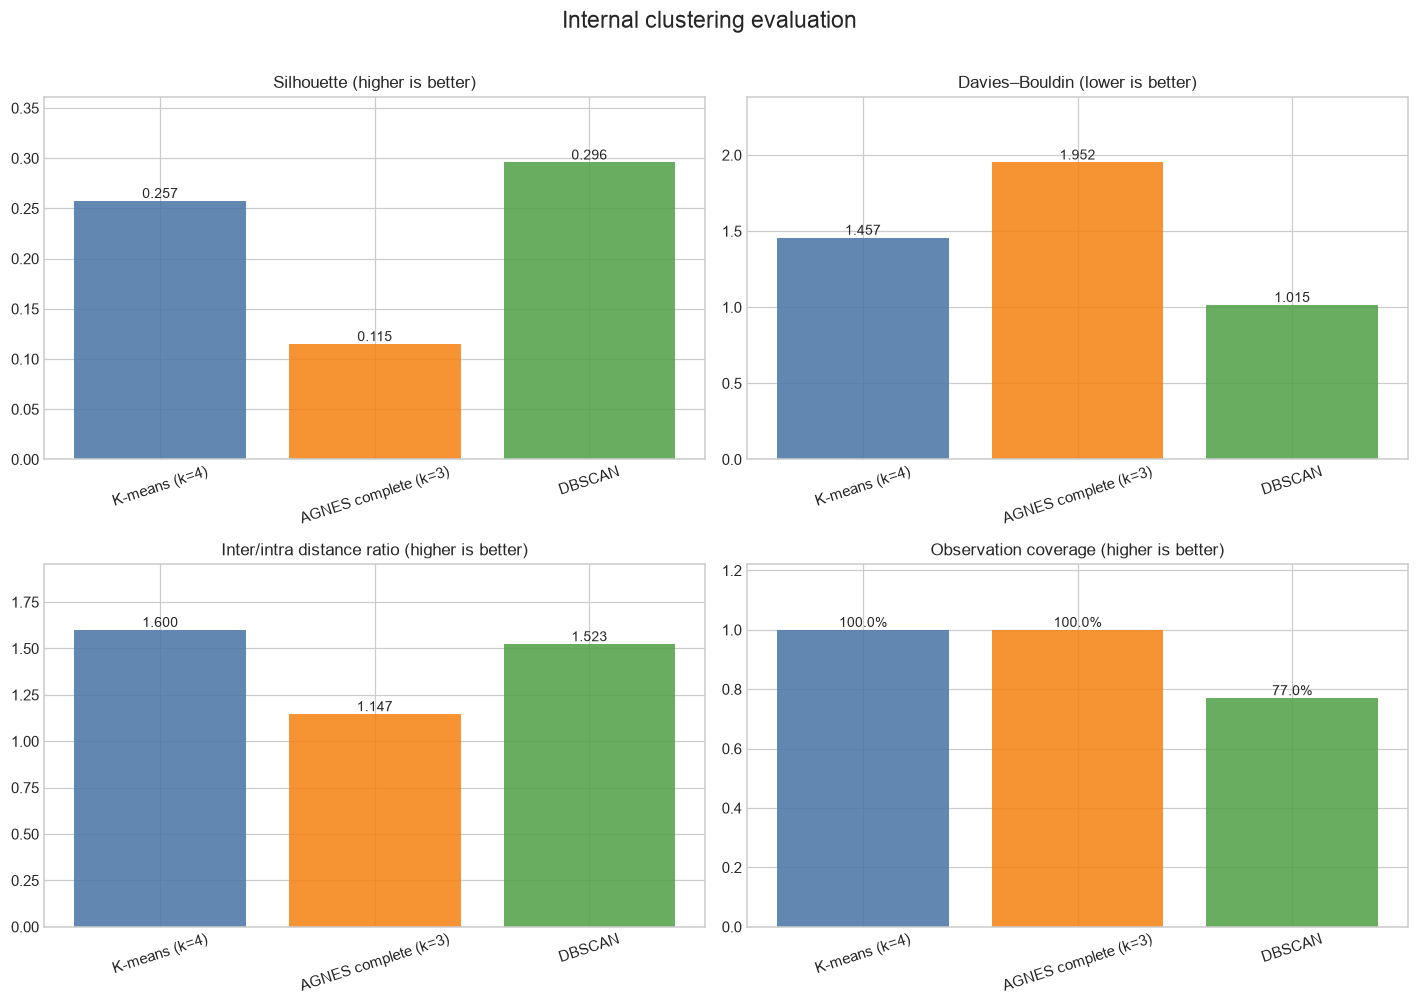

In [42]:
method_colors = [BLUE, ORANGE, TEAL]
comparison_panels = [
    ("silhouette", "Silhouette (higher is better)"),
    ("davies_bouldin", "Davies–Bouldin (lower is better)"),
    ("inter_intra_ratio", "Inter/intra distance ratio (higher is better)"),
    ("coverage", "Observation coverage (higher is better)"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for axis, (metric, title) in zip(axes.flat, comparison_panels):
    values = evaluation_results[metric]
    bars = axis.bar(evaluation_results.index, values, color=method_colors, alpha=0.88)
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=18)
    axis.set_ylim(0, max(values) * 1.22)
    for bar, value in zip(bars, values):
        label = f"{value:.1%}" if metric == "coverage" else f"{value:.3f}"
        axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label,
                  ha="center", va="bottom", fontsize=9)
fig.suptitle("Internal clustering evaluation", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## Part 3.2 — Cluster-size distributions

DBSCAN noise is displayed alongside its clusters so the loss of coverage is visible. Cluster numbers are algorithm-specific and are not intended to correspond across methods.

,method,cluster,label,days,share_of_all_days
0,K-means,0,Cluster 0,107,0.146375
1,K-means,1,Cluster 1,274,0.374829
2,K-means,2,Cluster 2,130,0.177839
3,K-means,3,Cluster 3,220,0.300958
4,AGNES complete,0,Cluster 0,373,0.510260
5,AGNES complete,1,Cluster 1,2,0.002736
6,AGNES complete,2,Cluster 2,356,0.487004
7,DBSCAN,-1,Noise,168,0.229822
8,DBSCAN,0,Cluster 0,426,0.582763
9,DBSCAN,1,Cluster 1,34,0.046512


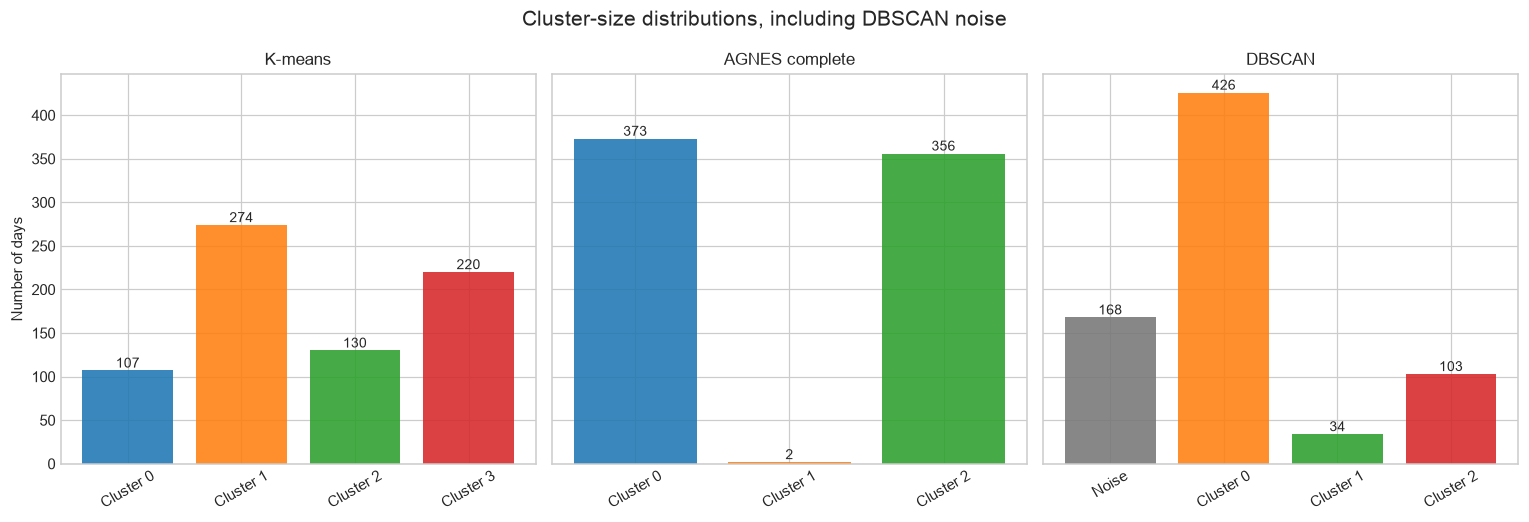

In [43]:
cluster_size_rows = []
for method_name, label_series in {
    "K-means": kmeans_labels,
    "AGNES complete": agnes_labels,
    "DBSCAN": dbscan_labels,
}.items():
    for cluster_label, count in label_series.value_counts().sort_index().items():
        cluster_size_rows.append({
            "method": method_name,
            "cluster": int(cluster_label),
            "label": "Noise" if cluster_label == -1 else f"Cluster {cluster_label}",
            "days": int(count),
            "share_of_all_days": count / len(label_series),
        })
cluster_size_distribution = pd.DataFrame(cluster_size_rows)
display(cluster_size_distribution)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
for axis, method_name in zip(axes, ["K-means", "AGNES complete", "DBSCAN"]):
    subset = cluster_size_distribution.query("method == @method_name")
    colors = ["#777777" if label == "Noise" else CLUSTER_CMAP(i)
              for i, label in enumerate(subset["label"])]
    bars = axis.bar(subset["label"], subset["days"], color=colors, alpha=0.88)
    axis.set_title(method_name)
    axis.tick_params(axis="x", rotation=30)
    for bar, days in zip(bars, subset["days"]):
        axis.text(bar.get_x() + bar.get_width() / 2, days, str(days),
                  ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Number of days")
fig.suptitle("Cluster-size distributions, including DBSCAN noise", fontsize=14)
fig.tight_layout()
plt.show()

## Part 3.3 — Stability and parameter sensitivity

Adjusted Rand Index (ARI) measures agreement with each selected solution while ignoring arbitrary cluster-number permutations. K-means is refitted across 20 seeds using 10 initialisations per seed. AGNES is perturbed through linkage and nearby cut choices. DBSCAN is compared with the alternative settings already investigated in Part 2. ARI near one indicates stable assignments.

In [44]:
stability_rows = []
for seed in range(20):
    alternative_labels = KMeans(
        n_clusters=KMEANS_FINAL_K, random_state=seed, n_init=10
    ).fit_predict(X_clustering)
    stability_rows.append({"method": "K-means", "perturbation": f"seed {seed}",
                           "adjusted_rand_index": adjusted_rand_score(kmeans_labels, alternative_labels)})

agnes_perturbations = [
    ("single linkage, k=3", "single", 3),
    ("average linkage, k=3", "average", 3),
    ("complete linkage, k=2", "complete", 2),
    ("complete linkage, k=4", "complete", 4),
]
for perturbation_name, linkage_method, clusters in agnes_perturbations:
    alternative_labels = AgglomerativeClustering(
        n_clusters=clusters, linkage=linkage_method, metric="euclidean"
    ).fit_predict(X_clustering)
    stability_rows.append({"method": "AGNES", "perturbation": perturbation_name,
                           "adjusted_rand_index": adjusted_rand_score(agnes_labels, alternative_labels)})

for setting_name, alternative_labels in dbscan_candidate_labels.items():
    if setting_name != "Primary":
        stability_rows.append({"method": "DBSCAN", "perturbation": setting_name,
                               "adjusted_rand_index": adjusted_rand_score(dbscan_labels, alternative_labels)})

stability_details = pd.DataFrame(stability_rows)
stability_summary = stability_details.groupby("method")["adjusted_rand_index"].agg(
    ["mean", "min", "max"]
).rename(columns={"mean": "mean_ARI", "min": "minimum_ARI", "max": "maximum_ARI"})
display(stability_summary.round(4))
display(stability_details.query("method != 'K-means'").round(4))

,mean_ARI,minimum_ARI,maximum_ARI
method,,,
AGNES,0.2533,0.0108,0.9808
DBSCAN,0.8164,0.7811,0.8525
K-means,0.9897,0.9789,1.0000


,method,perturbation,adjusted_rand_index
20,AGNES,"single linkage, k=3",0.0109
21,AGNES,"average linkage, k=3",0.0109
22,AGNES,"complete linkage, k=2",0.0108
23,AGNES,"complete linkage, k=4",0.9808
24,DBSCAN,Smaller eps,0.7811
25,DBSCAN,Larger eps,0.8157
26,DBSCAN,Lower min_samples,0.8525


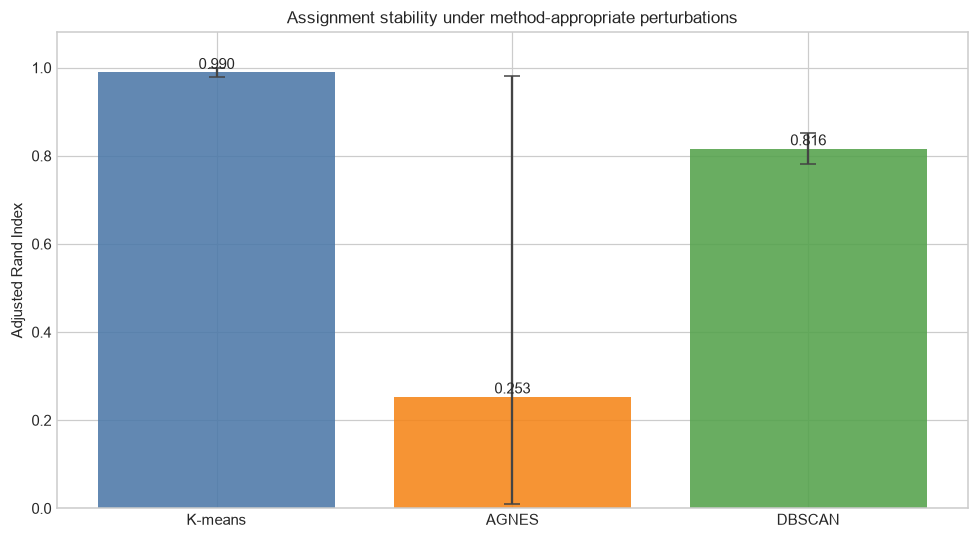

In [45]:
fig, axis = plt.subplots(figsize=(9, 5))
stability_plot = stability_summary.reindex(["K-means", "AGNES", "DBSCAN"])
bars = axis.bar(stability_plot.index, stability_plot["mean_ARI"], color=method_colors, alpha=0.88)
axis.errorbar(
    x=np.arange(len(stability_plot)), y=stability_plot["mean_ARI"],
    yerr=[stability_plot["mean_ARI"] - stability_plot["minimum_ARI"],
          stability_plot["maximum_ARI"] - stability_plot["mean_ARI"]],
    fmt="none", ecolor="#444444", capsize=5, linewidth=1.5,
)
for bar, value in zip(bars, stability_plot["mean_ARI"]):
    axis.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}",
              ha="center", va="bottom")
axis.set_ylim(0, 1.08)
axis.set_ylabel("Adjusted Rand Index")
axis.set_title("Assignment stability under method-appropriate perturbations")
fig.tight_layout()
plt.show()

## Part 3.4 — Overall comparison

In [46]:
method_comparison = pd.DataFrame({
    "K-means (k=4)": {
        "separation_and_compactness": "Good overall; inter/intra ratio 1.60",
        "parameter_sensitivity": "Low across random seeds",
        "cluster_balance": "Best balance; all four groups substantial",
        "interpretability": "Four clear demand/commuting/leisure regimes",
        "unusual_observations": "Assigned to nearest cluster; must be reviewed separately",
    },
    "AGNES complete (k=3)": {
        "separation_and_compactness": "Weakest internal validity and distance ratio",
        "parameter_sensitivity": "High sensitivity to linkage and cut",
        "cluster_balance": "Two large groups plus a two-day cluster",
        "interpretability": "Hierarchy is useful, final cut is less informative",
        "unusual_observations": "Explicit two-day extreme branch",
    },
    "DBSCAN": {
        "separation_and_compactness": "Strongest validity after excluding noise",
        "parameter_sensitivity": "Moderate; cluster/noise counts change with settings",
        "cluster_balance": "Imbalanced and covers only 77% as clusters",
        "interpretability": "Useful dense regimes, but 168 days remain ungrouped",
        "unusual_observations": "Best explicit treatment through noise label",
    },
}).T
display(method_comparison)

,separation_and_compactness,parameter_sensitivity,cluster_balance,interpretability,unusual_observations
K-means (k=4),Good overall; inter/intra ratio 1.60,Low across random seeds,Best balance; all four groups substantial,Four clear demand/commuting/leisure regimes,Assigned to nearest cluster; must be reviewed ...
AGNES complete (k=3),Weakest internal validity and distance ratio,High sensitivity to linkage and cut,Two large groups plus a two-day cluster,"Hierarchy is useful, final cut is less informa...",Explicit two-day extreme branch
DBSCAN,Strongest validity after excluding noise,Moderate; cluster/noise counts change with set...,Imbalanced and covers only 77% as clusters,"Useful dense regimes, but 168 days remain ungr...",Best explicit treatment through noise label


## Selected clustering result

**K-means with four clusters is selected as the most suitable overall result.** DBSCAN has the highest silhouette and lowest Davies–Bouldin value among its non-noise observations, but those scores describe only 563 of 731 days; 168 days (23%) are excluded and its cluster sizes are strongly imbalanced. Complete-linkage AGNES has the weakest validity, is highly sensitive to linkage choice, and isolates a two-day cluster.

K-means offers the strongest practical compromise: complete coverage, the most balanced cluster sizes, good separation relative to compactness, very high stability across initialisations, and four interpretable mobility regimes. Its inability to label noise is retained as a limitation; DBSCAN's noise list will be used as supporting information when unusual days are discussed.

In [47]:
SELECTED_CLUSTERING_METHOD = "K-means (k=4)"
selected_cluster_labels = kmeans_labels.copy().rename("selected_cluster")
selected_clustering_model = kmeans_model
selected_cluster_profiles = kmeans_centroids_original.copy()

assert evaluation_results.loc["K-means (k=4)", "coverage"] == 1.0
assert evaluation_results.loc["DBSCAN", "evaluated_observations"] == 563
assert selected_cluster_labels.index.equals(daily_mobility_features.index)
assert selected_cluster_labels.nunique() == 4
print(f"Selected method: {SELECTED_CLUSTERING_METHOD}")
print("Part 3 evaluation and comparison completed successfully.")

Selected method: K-means (k=4)
Part 3 evaluation and comparison completed successfully.


### Part 3 conclusion

The selected K-means result will be profiled in original units and validated against weekday, weekend, holiday, season, and weather context in Part 4.

# Part 4 — Cluster interpretation and validation

The selected four-cluster K-means solution is interpreted using original, non-standardized mobility features. Calendar and weather variables that were deliberately excluded from clustering are now used as external context to validate the behavioural meaning of each cluster.

## Part 4.1 — Original-scale cluster profiles and final names

In [51]:
cluster_names = {
    0: "Cool low-demand weekend days",
    1: "Warm high-demand commuter days",
    2: "Warm high-demand leisure days",
    3: "Cool registered-commuter days",
}
cluster_short_names = {
    0: "C0: Low-demand weekends",
    1: "C1: High-demand commuters",
    2: "C2: High-demand leisure",
    3: "C3: Cool commuters",
}

selected_profile_data = daily_mobility_features.join(selected_cluster_labels)
cluster_profile_original = selected_profile_data.groupby("selected_cluster").mean()
cluster_profile_original.insert(0, "days", selected_cluster_labels.value_counts().sort_index())
cluster_profile_original.insert(0, "cluster_name", pd.Series(cluster_names))
display(cluster_profile_original.round(3))

cluster_name_table = pd.DataFrame({
    "cluster": list(cluster_names),
    "descriptive_name": list(cluster_names.values()),
    "days": [int(selected_cluster_labels.eq(cluster).sum()) for cluster in cluster_names],
}).set_index("cluster")
display(cluster_name_table)

,cluster_name,days,total_daily_rentals,average_hourly_rentals,maximum_hourly_rentals,hourly_rental_std,morning_peak_share,evening_peak_share,off_peak_rental_share,casual_user_proportion,registered_user_proportion,average_temperature,average_humidity,average_wind_speed
selected_cluster,,,,,,,,,,,,,,
0,Cool low-demand weekend days,107,2471.495,102.979,258.112,82.724,0.082,0.249,0.668,0.204,0.796,0.305,0.609,0.217
1,Warm high-demand commuter days,274,5757.489,239.895,684.686,193.110,0.228,0.369,0.403,0.155,0.845,0.637,0.636,0.174
2,Warm high-demand leisure days,130,5652.723,235.530,514.015,175.029,0.075,0.279,0.646,0.357,0.643,0.612,0.639,0.172
3,Cool registered-commuter days,220,3253.741,135.573,413.541,114.332,0.268,0.347,0.385,0.080,0.920,0.343,0.621,0.210


,descriptive_name,days
cluster,,
0,Cool low-demand weekend days,107
1,Warm high-demand commuter days,274
2,Warm high-demand leisure days,130
3,Cool registered-commuter days,220


The table above is the primary cluster profile in original units. The heatmap below standardizes only the four cluster means for visual comparison; it does not replace the original-scale values.

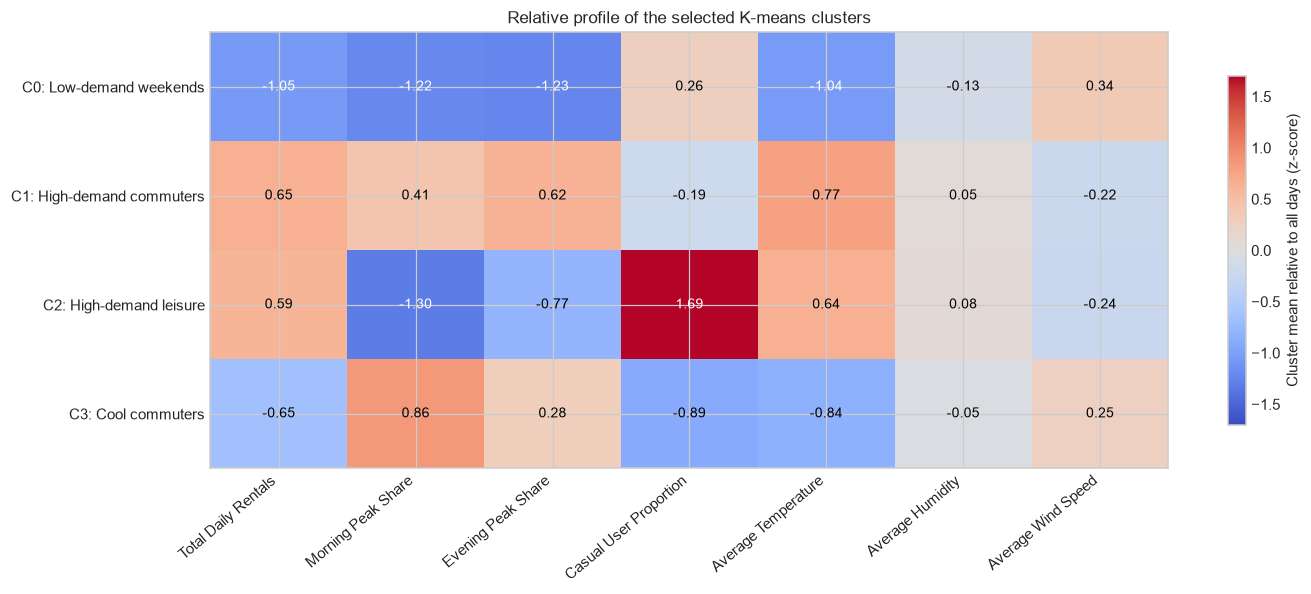

In [52]:
cluster_selected_means = (
    clustering_data_original.join(selected_cluster_labels)
    .groupby("selected_cluster")[selected_feature_columns].mean()
)
cluster_profile_z = pd.DataFrame(
    clustering_scaler.transform(cluster_selected_means),
    index=cluster_selected_means.index, columns=selected_feature_columns,
)

fig, axis = plt.subplots(figsize=(13, 5.5))
image = axis.imshow(cluster_profile_z, cmap="coolwarm", vmin=-1.7, vmax=1.7, aspect="auto")
axis.set_xticks(range(len(selected_feature_columns)),
                labels=[name.replace("_", " ").title() for name in selected_feature_columns],
                rotation=40, ha="right")
axis.set_yticks(range(4), labels=[cluster_short_names[i] for i in range(4)])
for row in range(cluster_profile_z.shape[0]):
    for column in range(cluster_profile_z.shape[1]):
        value = cluster_profile_z.iloc[row, column]
        axis.text(column, row, f"{value:.2f}", ha="center", va="center",
                  color="white" if abs(value) > 0.9 else "black", fontsize=9)
colorbar = fig.colorbar(image, ax=axis, shrink=0.8)
colorbar.set_label("Cluster mean relative to all days (z-score)")
axis.set_title("Relative profile of the selected K-means clusters")
fig.tight_layout()
plt.show()

## Part 4.2 — Average hourly mobility behaviour

The four mean 24-hour profiles provide a direct behavioural check on the engineered peak-share features.

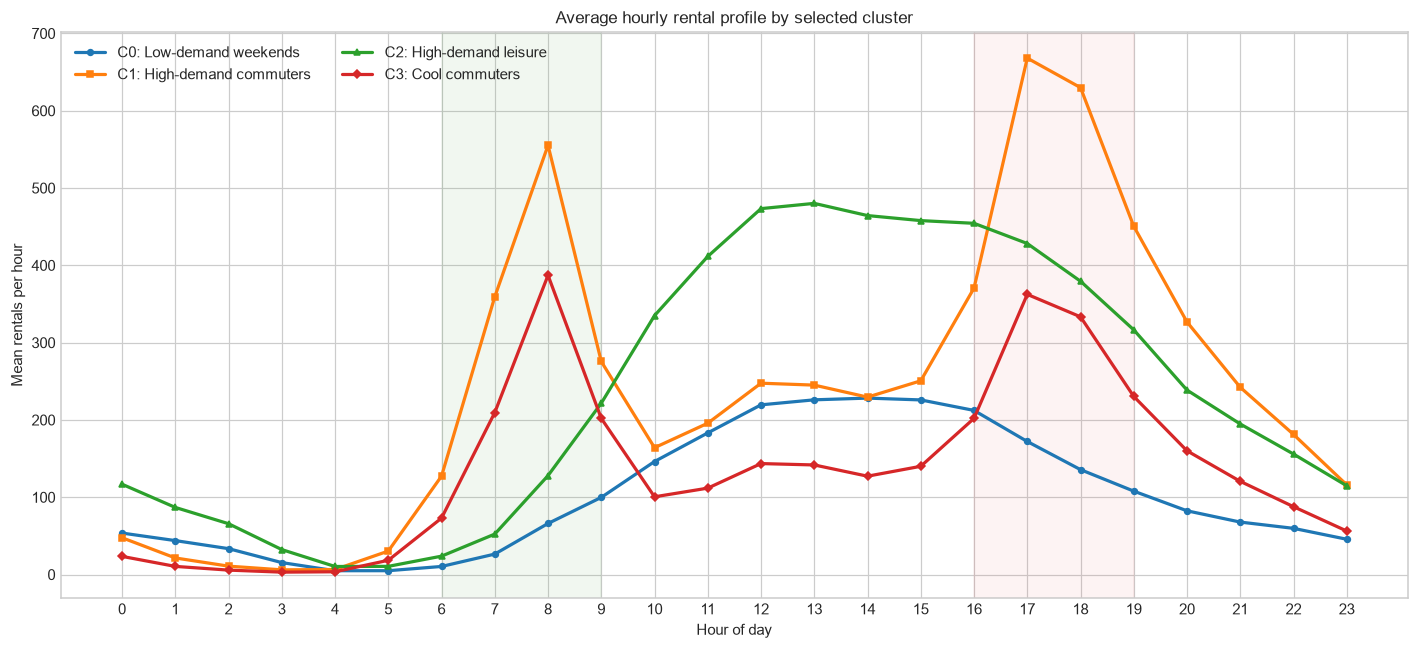

In [53]:
hourly_selected_clusters = hourly_24h.merge(
    selected_cluster_labels, left_on="dteday", right_index=True,
    how="left", validate="many_to_one"
)
cluster_hourly_profiles = (
    hourly_selected_clusters.groupby(["selected_cluster", "hr"])["cnt"]
    .mean().unstack(0)
)

fig, axis = plt.subplots(figsize=(13, 6))
markers = ["o", "s", "^", "D"]
for cluster in range(4):
    axis.plot(cluster_hourly_profiles.index, cluster_hourly_profiles[cluster],
              color=CLUSTER_CMAP(cluster), marker=markers[cluster], markersize=3.8,
              linewidth=2.1, label=cluster_short_names[cluster])
axis.axvspan(6, 9, color=TEAL, alpha=0.08)
axis.axvspan(16, 19, color=RED, alpha=0.07)
axis.set_xticks(range(24))
axis.set_xlabel("Hour of day")
axis.set_ylabel("Mean rentals per hour")
axis.set_title("Average hourly rental profile by selected cluster")
axis.legend(ncol=2)
fig.tight_layout()
plt.show()

## Part 4.3 — Calendar, season, and weather validation

Weekday, weekend, holiday, season, and weather were not used to form the clusters. Their distributions therefore provide an external behavioural validation. `dominant_weather` is the most frequent hourly weather category for each day.

In [54]:
cluster_context = daily_context.join(selected_cluster_labels)
cluster_context["day_type"] = np.select(
    [cluster_context["holiday"].eq(1), cluster_context["weekend"].eq(1)],
    ["Holiday", "Weekend"], default="Working weekday"
)

context_binary_summary = cluster_context.groupby("selected_cluster").agg(
    workingday_share=("workingday", "mean"),
    weekend_share=("weekend", "mean"),
    holiday_share=("holiday", "mean"),
    complete_day_share=("is_complete_day", "mean"),
)
day_type_distribution = pd.crosstab(
    cluster_context["selected_cluster"], cluster_context["day_type"], normalize="index"
).reindex(columns=["Working weekday", "Weekend", "Holiday"], fill_value=0)
season_distribution = pd.crosstab(
    cluster_context["selected_cluster"], cluster_context["season"], normalize="index"
).reindex(columns=[1, 2, 3, 4], fill_value=0).rename(
    columns={1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
)
weather_distribution = pd.crosstab(
    cluster_context["selected_cluster"], cluster_context["dominant_weather"], normalize="index"
).reindex(columns=[1, 2, 3, 4], fill_value=0).rename(columns={
    1: "Clear/partly cloudy", 2: "Mist/cloudy",
    3: "Light rain/snow", 4: "Severe weather",
})
weekday_distribution = pd.crosstab(
    cluster_context["selected_cluster"], cluster_context["weekday"], normalize="index"
).reindex(columns=range(7), fill_value=0).rename(columns={
    0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed",
    4: "Thu", 5: "Fri", 6: "Sat",
})

print("Independent context shares")
display(context_binary_summary.round(3))
print("Season distribution")
display(season_distribution.round(3))
print("Dominant weather distribution")
display(weather_distribution.round(3))
print("Weekday distribution")
display(weekday_distribution.round(3))

Independent context shares


,workingday_share,weekend_share,holiday_share,complete_day_share
selected_cluster,,,,
0,0.075,0.832,0.093,0.804
1,0.989,0.000,0.011,0.985
2,0.015,0.931,0.054,0.985
3,0.995,0.000,0.005,0.777


Season distribution


season,Spring,Summer,Fall,Winter
selected_cluster,,,,
0,0.589,0.075,0.009,0.327
1,0.026,0.350,0.460,0.164
2,0.031,0.354,0.431,0.185
3,0.486,0.155,0.023,0.336


Dominant weather distribution


dominant_weather,Clear/partly cloudy,Mist/cloudy,Light rain/snow,Severe weather
selected_cluster,,,,
0,0.682,0.224,0.093,0
1,0.818,0.168,0.015,0
2,0.838,0.154,0.008,0
3,0.641,0.273,0.086,0


Weekday distribution


weekday,Sun,Mon,Tue,Wed,Thu,Fri,Sat
selected_cluster,,,,,,,
0,0.411,0.084,0.019,0.009,0.019,0.037,0.421
1,0.000,0.197,0.212,0.190,0.197,0.204,0.000
2,0.469,0.046,0.000,0.008,0.000,0.015,0.462
3,0.000,0.164,0.200,0.227,0.218,0.191,0.000


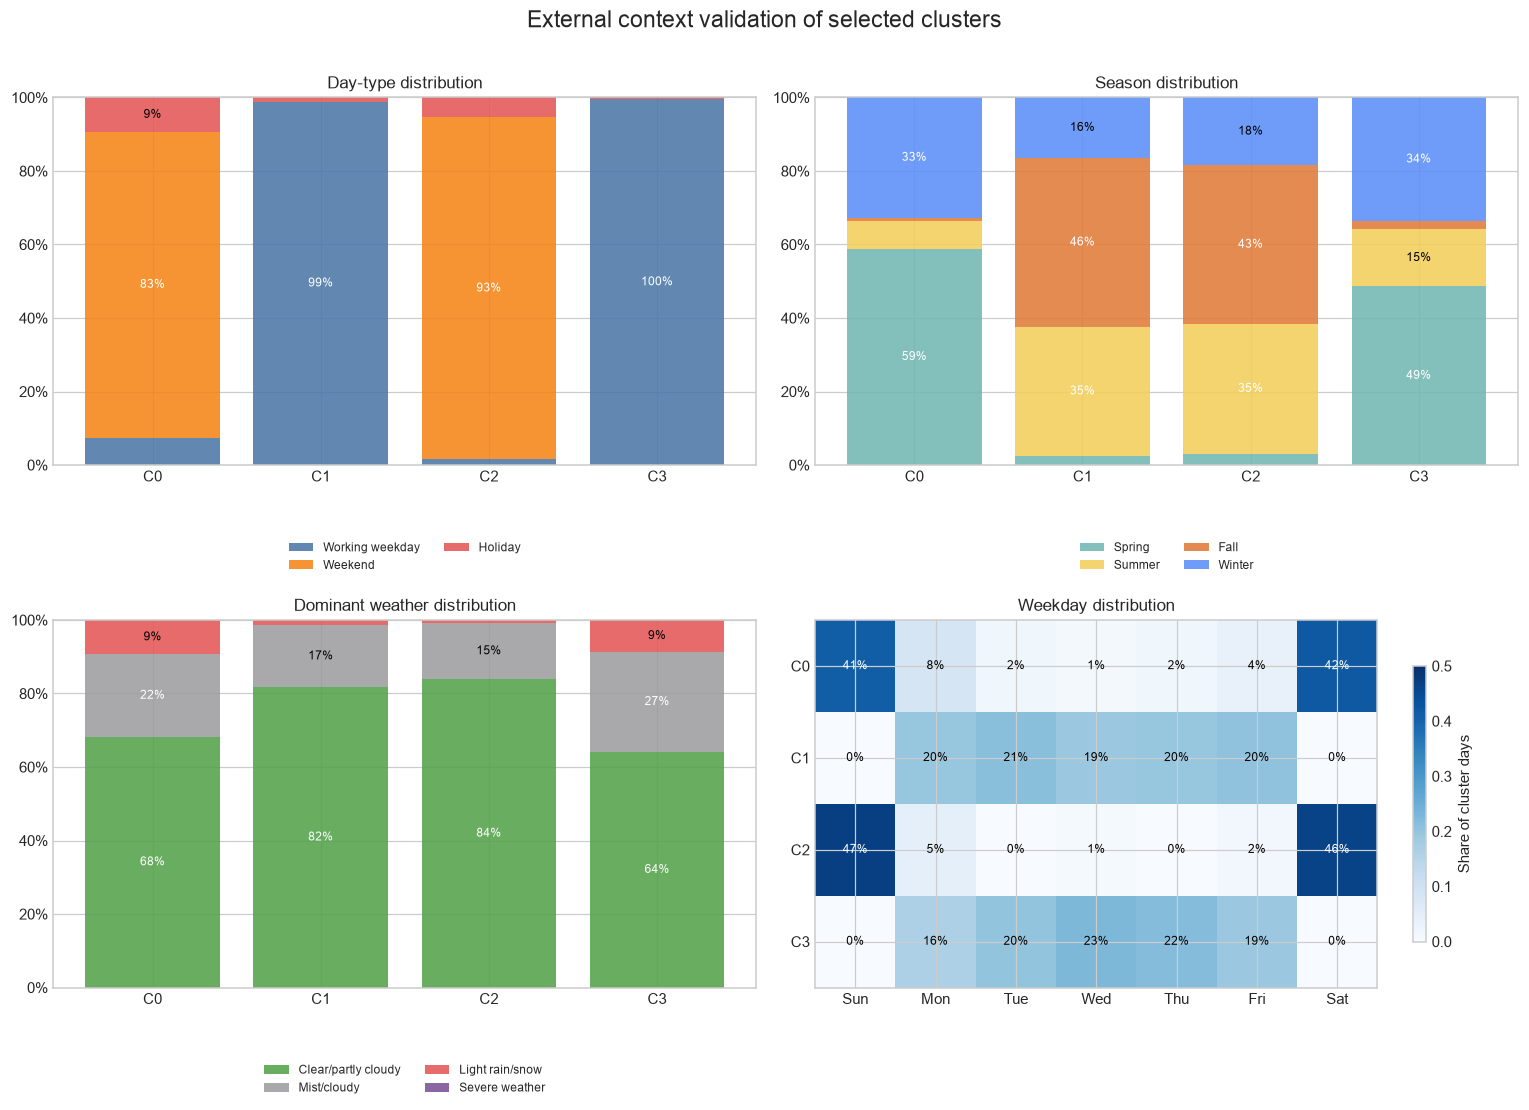

In [55]:
from matplotlib.ticker import PercentFormatter

def plot_stacked_context(axis, table, title, colors):
    bottom = np.zeros(len(table))
    x_positions = np.arange(len(table))
    for category, color in zip(table.columns, colors):
        values = table[category].to_numpy()
        axis.bar(x_positions, values, bottom=bottom, label=category, color=color, alpha=0.88)
        for x, base, value in zip(x_positions, bottom, values):
            if value >= 0.08:
                axis.text(x, base + value / 2, f"{value:.0%}", ha="center", va="center",
                          fontsize=8, color="white" if value > 0.20 else "black")
        bottom += values
    axis.set_xticks(x_positions, labels=[f"C{i}" for i in table.index])
    axis.set_ylim(0, 1)
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    axis.set_title(title)
    axis.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_stacked_context(
    axes[0, 0], day_type_distribution, "Day-type distribution",
    [BLUE, ORANGE, RED],
)
plot_stacked_context(
    axes[0, 1], season_distribution, "Season distribution",
    ["#72B7B2", "#F2CF5B", "#E07B39", "#5B8FF9"],
)
plot_stacked_context(
    axes[1, 0], weather_distribution, "Dominant weather distribution",
    ["#54A24B", "#9D9DA0", "#E45756", "#7A5195"],
)
weekday_image = axes[1, 1].imshow(weekday_distribution, cmap="Blues", vmin=0, vmax=0.5,
                                     aspect="auto")
axes[1, 1].set_xticks(range(7), labels=weekday_distribution.columns)
axes[1, 1].set_yticks(range(4), labels=[f"C{i}" for i in weekday_distribution.index])
axes[1, 1].set_title("Weekday distribution")
for row in range(weekday_distribution.shape[0]):
    for column in range(weekday_distribution.shape[1]):
        value = weekday_distribution.iloc[row, column]
        axes[1, 1].text(column, row, f"{value:.0%}", ha="center", va="center",
                             color="white" if value > 0.28 else "black", fontsize=8)
fig.colorbar(weekday_image, ax=axes[1, 1], shrink=0.75, label="Share of cluster days")
fig.suptitle("External context validation of selected clusters", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## Part 4.4 — Behaviour represented by each cluster

### Cluster 0 — Cool low-demand weekend days

This 107-day cluster averages about 2,471 rentals. Approximately 83% of its days are weekends, 59% occur in spring, and another 33% occur in winter. About 67% of rentals occur off peak and the casual-user share is 20%. It therefore represents cooler low-demand weekend or holiday activity, sometimes accompanied by less favourable weather.

### Cluster 1 — Warm high-demand commuter days

This is the largest cluster with 274 days and about 5,757 daily rentals. Nearly 99% are working days, mostly in summer or fall. Morning and evening windows account for roughly 60% of demand, and registered users contribute about 85%. The two sharp hourly peaks confirm a high-volume commuting regime.

### Cluster 2 — Warm high-demand leisure days

These 130 days average about 5,653 rentals but have a very different shape from Cluster 1. Approximately 93% are weekends, the casual-user share reaches 36%, and around 65% of demand occurs off peak. The broad midday profile and warm-season concentration indicate leisure, tourism, and recreational use.

### Cluster 3 — Cool registered-commuter days

This 220-day cluster averages about 3,254 rentals. More than 99% are working days, registered users supply 92% of rentals, and it has the strongest morning peak share. Spring and winter dominate. It represents routine commuting under cooler conditions and lower overall demand than the warm commuter cluster.

The calendar distributions strongly validate the behavioural distinction: Clusters 1 and 3 are workday regimes, while Clusters 0 and 2 are weekend-dominated. Weather is a secondary influence rather than the sole cluster driver; the cooler clusters contain somewhat more mist and light precipitation.

## Part 4.5 — Practical mobility insights

In [56]:
practical_insights = pd.DataFrame([
    {
        "planning_area": "Peak availability and rebalancing",
        "evidence": "Clusters 1 and 3 are almost entirely working days with sharp morning and evening peaks.",
        "recommended_action": "Pre-position bicycles before the morning commute and rebalance toward residential areas before the evening return peak; allocate the greatest capacity on warm Cluster 1 days.",
    },
    {
        "planning_area": "Weekend and leisure demand",
        "evidence": "Cluster 2 combines high demand, 93% weekends, a 36% casual share, and a broad midday profile.",
        "recommended_action": "Shift weekend capacity toward recreational, tourist, and mixed-use destinations and schedule rebalancing around the midday plateau rather than commuter peaks.",
    },
    {
        "planning_area": "Maintenance scheduling",
        "evidence": "Cluster 0 has the lowest demand and is dominated by cool spring/winter weekends and holidays.",
        "recommended_action": "Use forecast Cluster 0 periods for planned bicycle and docking-station maintenance, while retaining a minimum service level for weekend users.",
    },
    {
        "planning_area": "Seasonal demand planning",
        "evidence": "Both high-demand clusters are concentrated in summer and fall, but their hourly shapes differ sharply.",
        "recommended_action": "Combine weather forecasts with the workday calendar: prepare commuter-oriented capacity for Cluster 1 and leisure-oriented capacity for Cluster 2 instead of using one generic high-demand plan.",
    },
])
display(practical_insights)

,planning_area,evidence,recommended_action
0,Peak availability and rebalancing,Clusters 1 and 3 are almost entirely working d...,Pre-position bicycles before the morning commu...
1,Weekend and leisure demand,"Cluster 2 combines high demand, 93% weekends, ...","Shift weekend capacity toward recreational, to..."
2,Maintenance scheduling,Cluster 0 has the lowest demand and is dominat...,Use forecast Cluster 0 periods for planned bic...
3,Seasonal demand planning,Both high-demand clusters are concentrated in ...,Combine weather forecasts with the workday cal...


The dataset contains system-wide counts rather than origin/destination station records. Consequently, the recommendations identify **when and what type** of rebalancing is needed; exact station-level movements would require station-level trip or inventory data.

In [57]:
assert cluster_profile_original.shape[0] == 4
assert cluster_name_table["days"].sum() == 731
assert np.allclose(day_type_distribution.sum(axis=1), 1.0)
assert np.allclose(season_distribution.sum(axis=1), 1.0)
assert np.allclose(weather_distribution.sum(axis=1), 1.0)
assert np.allclose(weekday_distribution.sum(axis=1), 1.0)
assert len(practical_insights) >= 2
print("Part 4 cluster interpretation and validation completed successfully.")

Part 4 cluster interpretation and validation completed successfully.


### Part 4 conclusion

The four selected clusters distinguish warm and cool demand levels while independently separating commuting from leisure behaviour. Calendar context provides especially strong external validation, and the profiles translate into distinct operational strategies rather than a single system-wide demand rule.